In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Бизнес-аналитика CRM данных

Цель этого этапа — перейти от описания данных к анализу бизнеса: оценить количество лидов, студентов, выручку, воронку продаж, эффективность источников, менеджеров, продуктов и причины потерь.

В качестве основной таблицы используем `analytics_base`, построенную на основе Deals с добавлением агрегированных звонков по контактам.

### План такой:
1. Загрузка данных
2. Общие KPI бизнеса
3. Маркетингово-продажная воронка: Клики → Лиды → Студенты
4. CRM-воронка по стадиям
5. Анализ временных рядов
6. Деньги: полученные и потенциально недополученные
7. Источники и реклама
8. Менеджеры
9. Звонки
10. Продукты
11. Причины потерь
12. Выводы и кандидаты на точки роста

`real_revenue` так же считаем только по студентам.

In [5]:
data_dir = r"C:\Users\Admin\Desktop\ICH\Учеба, курсы в записи, домашки\Финальный проект\дополнительные файлы"

# Основная аналитическая база analytics_base построена на основе Deals с добавлением агрегированных звонков по контакту.
analytics_base_path = os.path.join(data_dir, "analytics_base.csv")
analytics_base = pd.read_csv(analytics_base_path, dtype={"id": "string", "contact_id": "string"})


# spend_by_source_campaign — это агрегированная таблица рекламных расходов по источнику и кампании, чтобы корректно сравнить затраты с лидами, студентами и выручкой
# Мы можем использовать эту агрегацию вместе с Deals и посмотреть:
# - какие источники и кампании привели больше всего лидов;
# - какие источники и кампании дали больше студентов;
# - сколько стоил лид по каждому источнику;
# - сколько стоил студент/buyer по каждому источнику;
# - какие кампании потратили много бюджета, но дали слабый результат;
# - где рекламный бюджет используется эффективнее.
spend_by_source_campaign_path = os.path.join(data_dir, "spend_by_source_campaign.csv")    
spend_by_source_campaign = pd.read_csv(spend_by_source_campaign_path)



# заранее созданная таблица calls_by_contact — это агрегированная таблица звонков по каждому клиенту.
# Это нужно ,чтобы мы смогли присоединить агрегацию к Deals и посмотреть:
# - влияет ли количество звонков на покупку;
# - сколько звонков нужно до оплаты;
# - у студентов больше успешных звонков или нет;
# - какие менеджеры/источники дают клиентов, которым сложнее дозвониться;
# - есть ли связь между звонками и воронкой.
calls_by_contact_path = os.path.join(data_dir, "calls_by_contact.csv")
calls_by_contact = pd.read_csv(calls_by_contact_path, dtype={"contact_id": "string"})

In [6]:
analytics_base["created_time"] = pd.to_datetime(analytics_base["created_time"], errors="coerce")

analytics_base["closing_date"] = pd.to_datetime(analytics_base["closing_date"], errors="coerce")

analytics_base["first_call_time"] = pd.to_datetime(analytics_base["first_call_time"], errors="coerce")

analytics_base["last_call_time"] = pd.to_datetime(analytics_base["last_call_time"], errors="coerce")

In [7]:
analytics_base.head()

,id,deal_owner_name,closing_date,quality,stage,lost_reason,page,campaign,sla,content,...,contact_id,city,level_of_deutsch,is_student,total_calls,successful_calls,avg_call_duration_sec,total_call_duration_sec,first_call_time,last_call_time
0,5805028000005176025,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,5805028000000872003,Unknown,Unknown,False,12.0,1.0,0.5,6.0,2023-07-05 19:19:00,2024-06-20 14:57:00
1,5805028000005168037,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,5805028000000872003,Unknown,Unknown,False,12.0,1.0,0.5,6.0,2023-07-05 19:19:00,2024-06-20 14:57:00
2,5805028000005174051,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,5805028000000872003,Unknown,Unknown,False,12.0,1.0,0.5,6.0,2023-07-05 19:19:00,2024-06-20 14:57:00
3,5805028000005180061,John Doe,NaT,E - Non Qualified,Registered on Webinar,NaN,/workshop,web2408_DE,5422.58,Unknown,...,5805028000000872003,Unknown,Unknown,False,12.0,1.0,0.5,6.0,2023-07-05 19:19:00,2024-06-20 14:57:00
4,5805028000005176076,John Doe,NaT,NaN,Registered on Webinar,NaN,/workshop,web2408_DE,NaN,Unknown,...,5805028000000872003,Unknown,Unknown,False,12.0,1.0,0.5,6.0,2023-07-05 19:19:00,2024-06-20 14:57:00


# Общие KPI бизнеса

In [8]:
total_deals = len(analytics_base)

total_contacts = analytics_base["contact_id"].nunique()

students_count = analytics_base["is_student"].sum()

student_conversion = round(students_count / total_deals * 100, 2)

total_revenue = analytics_base.loc[analytics_base["is_student"], "initial_amount_paid"].sum()

avg_payment = analytics_base.loc[analytics_base["is_student"], "initial_amount_paid"].mean()

median_payment = analytics_base.loc[analytics_base["is_student"], "initial_amount_paid"].median()

kpi_summary = pd.DataFrame({
    "metric": [
        "Потенциальных сделок",
        "Уникальных контактов",
        "Студентов / buyers",
        "Конверсия в студента, %",
        "Выручка по первому платежу",
        "Средний первый платеж",
        "Медианный первый платеж"],
    "value": [
        total_deals,
        total_contacts,
        students_count,
        student_conversion,
        round(total_revenue, 2),
        round(avg_payment, 2),
        round(median_payment, 2)]})

kpi_summary

,metric,value
0,Потенциальных сделок,19824.00
1,Уникальных контактов,16985.00
2,Студентов / buyers,840.00
3,"Конверсия в студента, %",4.24
4,Выручка по первому платежу,950350.00
5,Средний первый платеж,1131.37
6,Медианный первый платеж,1000.00


## Первичный вывод по KPI

Основной объем CRM состоит из потенциальных сделок.  
Buyer/студентом считаем клиента, у которого заполнен `months_of_study`, то есть человек фактически начал обучение.
Выручку считаем по `initial_amount_paid` только для студентов, потому что по условиям проекта деньги по сделкам без факта обучения учитывать нельзя.

# Воронки продаж 
## У нас 2 вороки продаж, 
* 1 - Бизнес-воронка (маркетингово-продажная воронка)

    CRM- маркетингово-продажная воронка (Клики → Лиды → Студенты) отвечает на вопрос - Как реклама превращается в лиды и студентов?

  
* 2 - Воронка продаж по стадиям

    Для Воронки продаж по стадиям используем столбец stage.
    Важно: stage показывает текущий/финальный статус потенциальной сделки в CRM.
    Для определения buyer используем не только stage, а главный признак фактического обучения — is_student.
    CRM-воронка по стадиям (Marketing / Lead → Active Sales → Payment Done / Student → Lost) отвечает на вопрос - Где в CRM находятся/теряются сделки?

## Бизнес-воронка (маркетингово-продажная воронка)

In [25]:
n_clicks = int(spend_by_source_campaign["total_clicks"].sum())
n_leads = int(len(analytics_base))
n_students = int(analytics_base["is_student"].sum())

conv_click_to_lead = n_leads / n_clicks * 100 if n_clicks else 0
conv_lead_to_student = n_students / n_leads * 100 if n_leads else 0

funnel_summary = pd.DataFrame({
    "stage": ["Клики", "Лиды", "Студенты"],
    "value": [n_clicks, n_leads, n_students],
    "conversion_from_previous": [np.nan, conv_click_to_lead, conv_lead_to_student]})

funnel_summary

,stage,value,conversion_from_previous
0,Клики,498455,NaN
1,Лиды,19824,3.977089
2,Студенты,840,4.237288


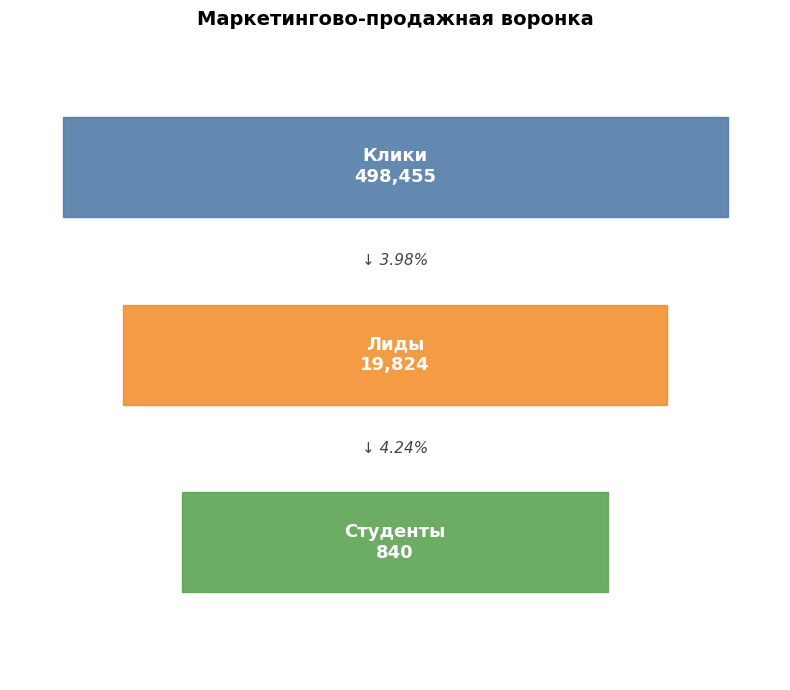

In [27]:
stages = ["Клики", "Лиды", "Студенты"]
values = [n_clicks, n_leads, n_students]
colors = ["#4e79a7", "#f28e2b", "#59a14f"]

conv_labels = [None, f"{conv_click_to_lead:.2f}%", f"{conv_lead_to_student:.2f}%"]

log_values = np.log1p(values)
half_widths = 0.25 + (log_values / log_values[0]) * 0.70

fig, ax = plt.subplots(figsize=(8, 7))
ax.axis("off")

block_h = 0.4
gap = 0.35
total_h = len(stages) * block_h + (len(stages) - 1) * gap

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-gap, total_h + 0.3)

for i, (stage, value, color, half_width) in enumerate(
    zip(stages, values, colors, half_widths)):
    y_bottom = total_h - (i + 1) * block_h - i * gap

    rect = plt.Rectangle((-half_width, y_bottom), 2 * half_width, block_h, color=color, alpha=0.88)
    ax.add_patch(rect)

    ax.text(0, y_bottom + block_h / 2, f"{stage}\n{value:,}", ha="center", va="center", fontsize=13, fontweight="bold", color="white")

    if conv_labels[i]:
        ax.text(0, y_bottom + block_h + gap / 2, f"↓ {conv_labels[i]}", ha="center", va="center", fontsize=11, color="#444444",fontstyle="italic")

ax.set_title("Маркетингово-продажная воронка", fontsize=14, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()


## Вывод по маркетингово-продажной воронке

Воронка `Клики → Лиды → Студенты` показывает, как рекламный трафик конвертируется в потенциальные сделки и фактических студентов.

Клики берутся из Spend, лиды — это строки в Deals, студенты — сделки с заполненным `months_of_study` (`is_student = True`).

Эта воронка позволяет оценить два ключевых перехода:
- эффективность превращения рекламного трафика в лиды;
- эффективность обработки лидов до фактического студента.

## Воронка продаж (по стадиям)

In [30]:
stage_funnel = (analytics_base["stage"].value_counts(dropna=False).reset_index())
stage_funnel.columns = ["stage", "deals_count"]
stage_funnel["deals_pct"] = (stage_funnel["deals_count"] / len(analytics_base) * 100).round(2)
stage_funnel

,stage,deals_count,deals_pct
0,Lost,13997,70.61
1,Call Delayed,2243,11.31
2,Registered on Webinar,2070,10.44
3,Payment Done,858,4.33
4,Waiting For Payment,324,1.63
5,Qualificated,128,0.65
6,Registered on Offline Day,85,0.43
7,Need to Call - Sales,33,0.17
8,Need To Call,31,0.16
9,Test Sent,25,0.13


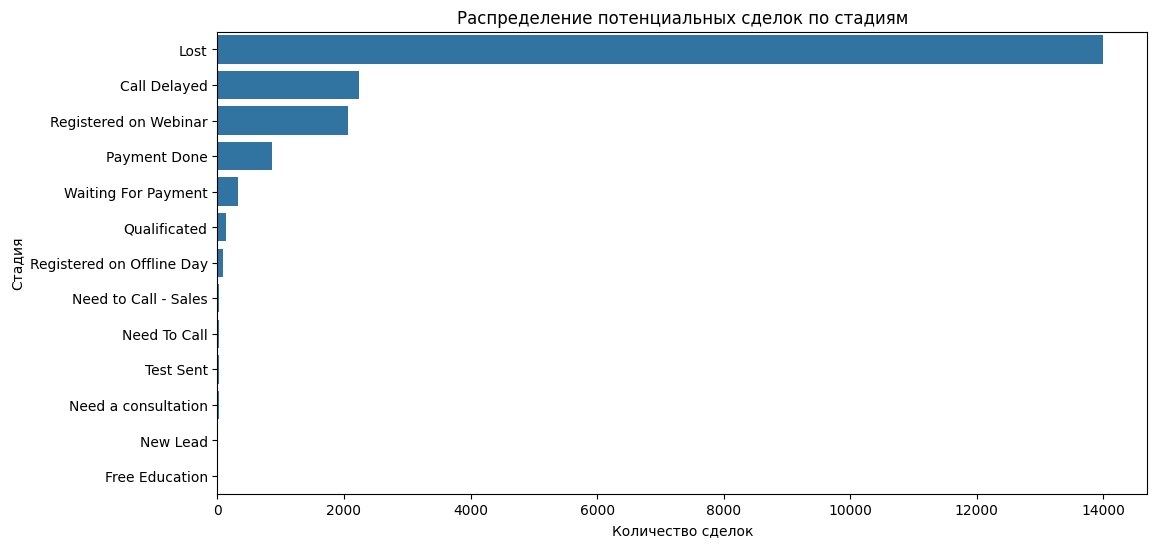

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(data=stage_funnel, x="deals_count", y="stage")
plt.title("Распределение потенциальных сделок по стадиям")
plt.xlabel("Количество сделок")
plt.ylabel("Стадия")
plt.show()

In [32]:
# Укрупняем стадии воронки, чтобы не работать с 13 статусами сразу (фактически сегментировать).
def stage_to_group(stage):
    if stage == "Payment Done":
        return "Won / Student"
    if stage == "Lost":
        return "Lost"
    if stage in ["Waiting For Payment", "Qualificated", "Need to Call - Sales", "Need To Call", "Need a consultation", "Test Sent", "Call Delayed"]:
        return "Active Sales"
    if stage in ["Registered on Webinar", "Registered on Offline Day", "New Lead", "Free Education"]:
        return "Marketing / Lead"
    return "Other"

In [33]:
analytics_base["stage_group"] = analytics_base["stage"].apply(stage_to_group)

In [34]:
stage_group_funnel = (analytics_base["stage_group"].value_counts().reset_index())
stage_group_funnel.columns = ["stage_group", "deals_count"]
stage_group_funnel["deals_pct"] = (stage_group_funnel["deals_count"] / len(analytics_base) * 100).round(2)
stage_group_funnel

,stage_group,deals_count,deals_pct
0,Lost,13997,70.61
1,Active Sales,2807,14.16
2,Marketing / Lead,2162,10.91
3,Won / Student,858,4.33


In [35]:
stage_group_order = ["Marketing / Lead", "Active Sales", "Won / Student", "Lost", "Other"]
stage_group_funnel["stage_group"] = pd.Categorical(stage_group_funnel["stage_group"], categories=stage_group_order, ordered=True)
stage_group_funnel = (stage_group_funnel.sort_values("stage_group").reset_index(drop=True))
stage_group_funnel

,stage_group,deals_count,deals_pct
0,Marketing / Lead,2162,10.91
1,Active Sales,2807,14.16
2,Won / Student,858,4.33
3,Lost,13997,70.61


In [36]:
stage_group_order = ["Won / Student", "Active Sales", "Marketing / Lead", "Lost", "Other"]

stage_group_plot = stage_group_students.copy()

stage_group_plot["stage_group"] = pd.Categorical(stage_group_plot["stage_group"],categories=stage_group_order, ordered=True)

stage_group_plot = (stage_group_plot.sort_values("stage_group").reset_index(drop=True))

stage_group_plot

,stage_group,deals_count,students_count,student_rate
0,Won / Student,858,840,97.9
1,Active Sales,2807,0,0.0
2,Marketing / Lead,2162,0,0.0
3,Lost,13997,0,0.0


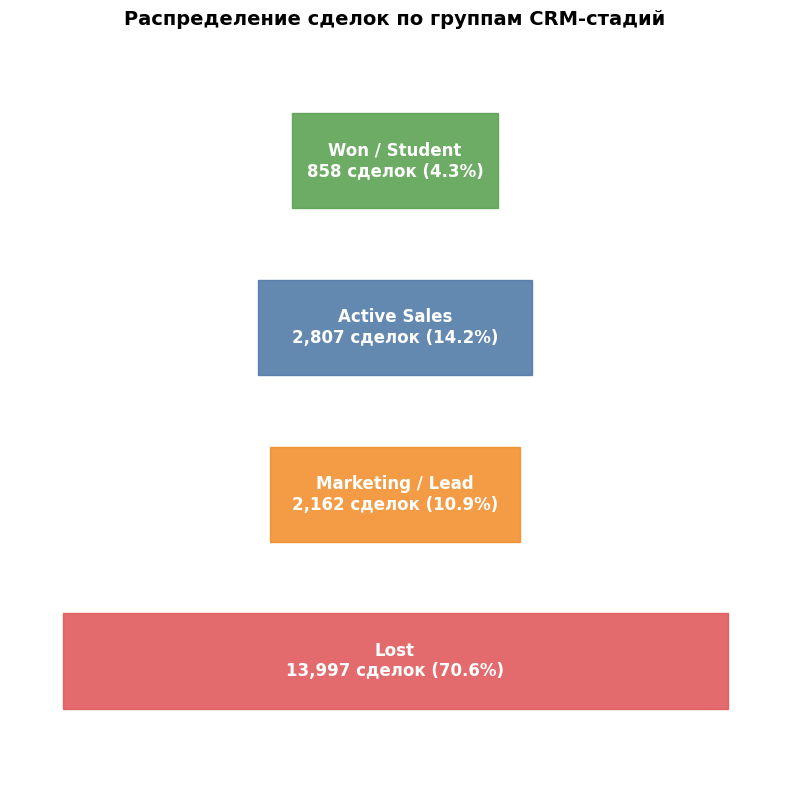

In [37]:
stages = stage_group_plot["stage_group"].astype(str).tolist()
values = stage_group_plot["deals_count"].tolist()
colors = ["#59a14f", "#4e79a7", "#f28e2b", "#e15759", "#bab0ab"]

max_value = max(values)
half_widths = [0.25 + (value / max_value) * 0.70
    for value in values]

fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("off")

block_h = 0.4
gap = 0.3
total_h = len(stages) * block_h + (len(stages) - 1) * gap

ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-gap, total_h + 0.3)

for i, (stage, value, color, half_width) in enumerate(zip(stages, values, colors, half_widths)):
    y_bottom = total_h - (i + 1) * block_h - i * gap

    rect = plt.Rectangle((-half_width, y_bottom), 2 * half_width, block_h, color=color, alpha=0.88)
    ax.add_patch(rect)

    pct = value / sum(values) * 100

    ax.text(0, y_bottom + block_h / 2, f"{stage}\n{value:,} сделок ({pct:.1f}%)", ha="center",
        va="center", fontsize=12, fontweight="bold", color="white")

ax.set_title("Распределение сделок по группам CRM-стадий", fontsize=14, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

## Вывод по CRM-стадиям

CRM-стадии были объединены в несколько бизнес-групп: `Won / Student`, `Active Sales`, `Marketing / Lead`, `Lost`.

Этот график показывает не последовательную воронку, а распределение текущих/финальных статусов сделок.  
Большая доля `Lost` означает, что основная масса потенциальных сделок закрывается без перехода в студенты, поэтому причины потерь нужно анализировать отдельно.

# Анализ временных рядов
На этом этапе анализируем динамику ключевых бизнес-показателей во времени:

- количество созданных сделок;
- количество студентов;
- конверсию в студента;
- количество звонков;
- количество успешных звонков;
- рекламные расходы, клики и показы.

Это помогает понять, как менялась активность бизнеса и связаны ли изменения в заявках, звонках и рекламе.

#### Дополнительно загружаем Calls и Spend для временных рядов

In [38]:
calls_path = os.path.join(data_dir, "calls_clean.csv")
spend_path = os.path.join(data_dir, "spend_clean.csv")

calls = pd.read_csv(calls_path, dtype={"id": "string", "contact_id": "string"})

spend = pd.read_csv(spend_path)

In [39]:
calls["call_start_time"] = pd.to_datetime(calls["call_start_time"], errors="coerce")

spend["date"] = pd.to_datetime(spend["date"], errors="coerce")

Теперь блок временных рядов.

In [42]:
# Создаем новый столбец created_month, где оставляем только месяц и год создания сделки.
# Например, из 2023-07-15 14:30 получаем 2023-07, чтобы потом смотреть динамику сделок по месяцам.
analytics_base["created_month"] = (analytics_base["created_time"].dt.to_period("M").astype(str))

# Создаем месяц звонка по дате начала звонка, чтобы потом посчитать, сколько звонков было в каждом месяце.
calls["call_month"] = (calls["call_start_time"].dt.to_period("M").astype(str))

# Создаем месяц рекламных расходов, чтобы потом сравнивать по месяцам расходы, клики, показы, сделки и студентов.
spend["month"] = (spend["date"].dt.to_period("M").astype(str))

In [43]:
# Группируем сделки по месяцу создания. Для каждого месяца считаем:
# deals_count — сколько всего сделок/лидов было создано в этом месяце.
# students_count — сколько из них стали студентами.
# Так как is_student содержит True/False, сумма True дает количество студентов.
deals_monthly = (analytics_base.groupby("created_month").agg(deals_count=("id", "count"), students_count=("is_student", "sum")).reset_index())

# Считаем конверсию из сделки/лида в студента по каждому месяцу.
deals_monthly["student_conversion"] = (deals_monthly["students_count"] / deals_monthly["deals_count"] * 100).round(2)

deals_monthly

,created_month,deals_count,students_count,student_conversion
0,2023-07,612,10,1.63
1,2023-08,931,48,5.16
2,2023-09,976,49,5.02
3,2023-10,1462,77,5.27
4,2023-11,1768,103,5.83
5,2023-12,1661,103,6.20
6,2024-01,2046,114,5.57
7,2024-02,1979,72,3.64
8,2024-03,2040,100,4.90
9,2024-04,2888,75,2.60


In [44]:
# Группируем звонки по месяцам. Для каждого месяца считаем:
# total_calls — сколько всего было звонков.
# successful_calls — сколько было успешных звонков.
calls_monthly = (calls.groupby("call_month").agg(total_calls=("id", "count"),successful_calls=("is_successful_call", "sum")).reset_index())

# Считаем процент успешных звонков в каждом месяце.
calls_monthly["successful_call_rate"] = (calls_monthly["successful_calls"] / calls_monthly["total_calls"] * 100).round(2)

calls_monthly

,call_month,total_calls,successful_calls,successful_call_rate
0,2023-06,7,6,85.71
1,2023-07,1923,1035,53.82
2,2023-08,4090,2401,58.70
3,2023-09,4978,2911,58.48
4,2023-10,6903,3952,57.25
5,2023-11,7009,4207,60.02
6,2023-12,6983,4809,68.87
7,2024-01,9609,6275,65.30
8,2024-02,9374,6069,64.74
9,2024-03,9556,6204,64.92


In [45]:
# Группируем рекламные данные по месяцам. Для каждого месяца считаем:
# total_spend — сколько денег потратили на рекламу.
# total_clicks — сколько получили кликов.
# total_impressions — сколько было показов рекламы.
spend_monthly = (spend.groupby("month").agg(total_spend=("spend", "sum"), total_clicks=("clicks", "sum"),
        total_impressions=("impressions", "sum")).reset_index())

spend_monthly


,month,total_spend,total_clicks,total_impressions
0,2023-07,6062.32,23553,1868812
1,2023-08,9033.73,35346,3506308
2,2023-09,8711.16,49103,5554229
3,2023-10,11807.78,50047,4028456
4,2023-11,10890.74,34108,2214167
5,2023-12,12186.03,42426,3598888
6,2024-01,12583.57,44298,4388750
7,2024-02,12476.83,40407,3609747
8,2024-03,16223.38,42920,4572666
9,2024-04,20964.65,61601,8463518


In [46]:
# Объединяем три месячные таблицы в одну:
# deals_monthly — сделки и студенты.
# calls_monthly — звонки.
# spend_monthly — реклама.
# how="outer" означает: сохраняем все месяцы, даже если в каком-то месяце есть реклама, но нет звонков, или есть звонки, но нет сделок.
monthly_analysis = (deals_monthly.merge(calls_monthly, left_on="created_month", right_on="call_month", how="outer")
    .merge(spend_monthly, left_on="created_month", right_on="month", how="outer"))


# Создаем единый столбец month. Почему это нужно: после объединения месяц может лежать в разных колонках:
# created_month — месяц сделки.
# call_month — месяц звонка.
# month — месяц рекламы.
# combine_first() берет первое непустое значение.
monthly_analysis["month"] = (monthly_analysis["created_month"].combine_first(monthly_analysis["call_month"])
    .combine_first(monthly_analysis["month"]))

# Наводим порядок в итоговой таблице:
# удаляем лишние технические колонки с месяцами;
# сортируем строки по месяцу;
# обновляем индекс таблицы.
monthly_analysis = (monthly_analysis.drop(columns=["created_month", "call_month"]).sort_values("month").reset_index(drop=True))

monthly_analysis


,deals_count,students_count,student_conversion,total_calls,successful_calls,successful_call_rate,month,total_spend,total_clicks,total_impressions
0,NaN,NaN,NaN,7,6,85.71,2023-06,NaN,NaN,NaN
1,612.0,10.0,1.63,1923,1035,53.82,2023-07,6062.32,23553.0,1868812.0
2,931.0,48.0,5.16,4090,2401,58.70,2023-08,9033.73,35346.0,3506308.0
3,976.0,49.0,5.02,4978,2911,58.48,2023-09,8711.16,49103.0,5554229.0
4,1462.0,77.0,5.27,6903,3952,57.25,2023-10,11807.78,50047.0,4028456.0
5,1768.0,103.0,5.83,7009,4207,60.02,2023-11,10890.74,34108.0,2214167.0
6,1661.0,103.0,6.20,6983,4809,68.87,2023-12,12186.03,42426.0,3598888.0
7,2046.0,114.0,5.57,9609,6275,65.30,2024-01,12583.57,44298.0,4388750.0
8,1979.0,72.0,3.64,9374,6069,64.74,2024-02,12476.83,40407.0,3609747.0
9,2040.0,100.0,4.90,9556,6204,64.92,2024-03,16223.38,42920.0,4572666.0


## визуализация временных рядов

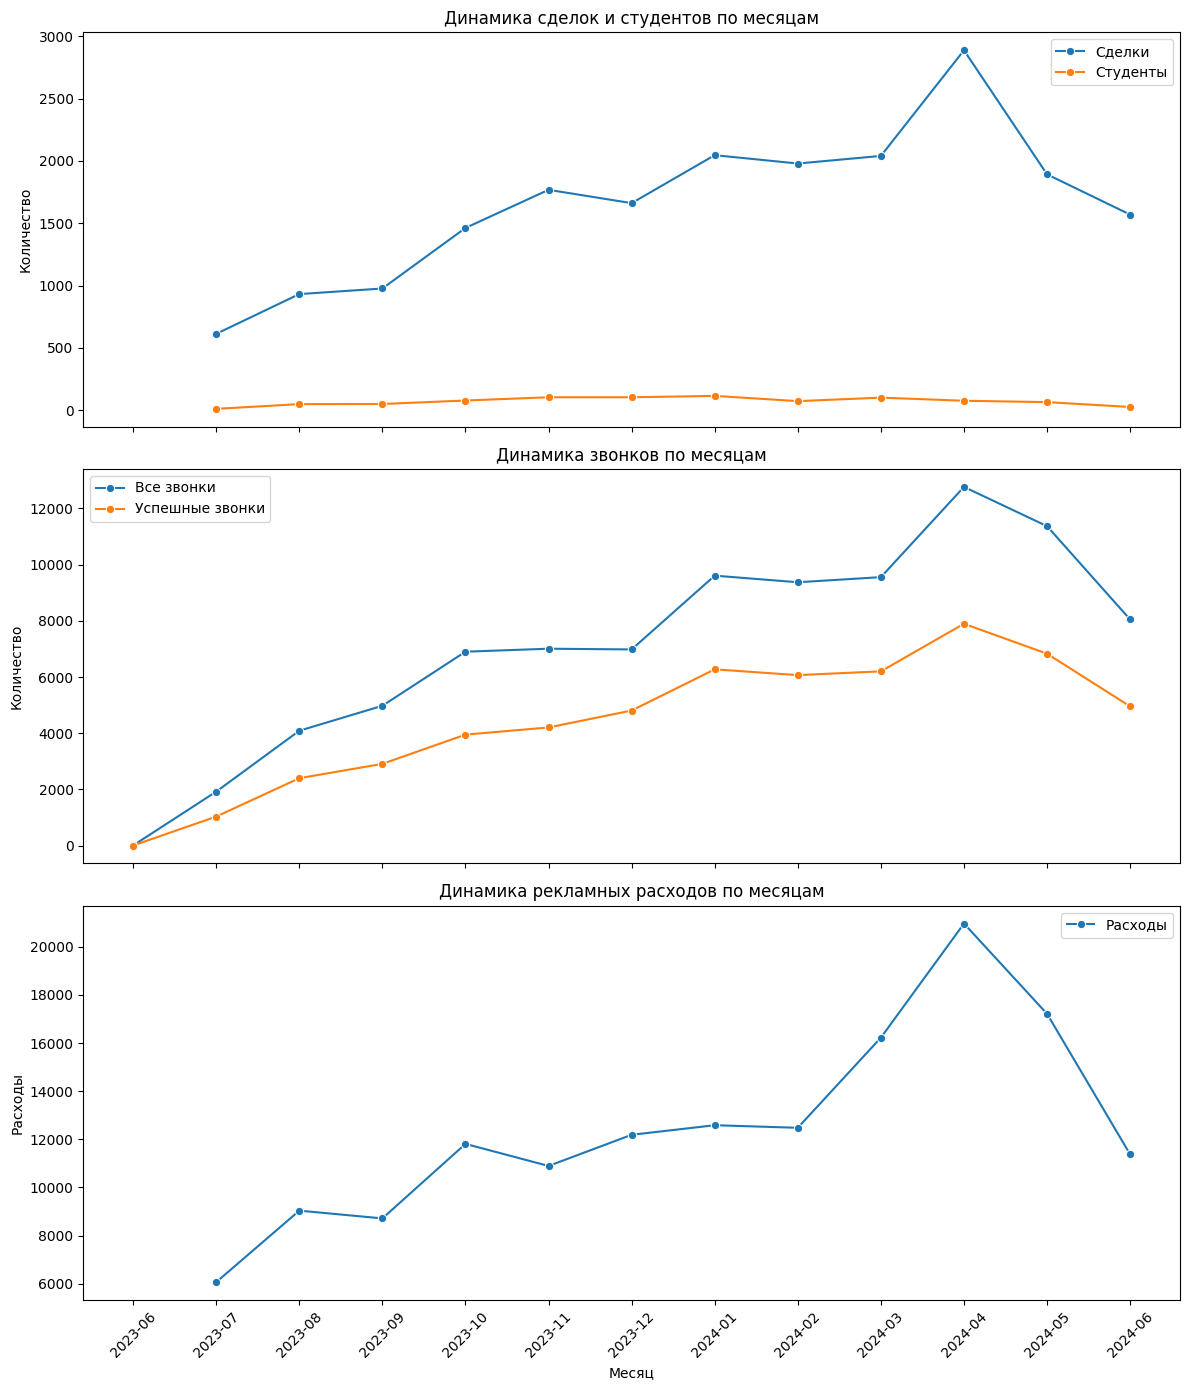

In [47]:
# Графики временных рядов.
fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

# Этот график показывает, как по месяцам менялось количество новых сделок и количество студентов.
# Он помогает понять, в какие месяцы было больше лидов, и превращались ли они в реальных студентов.
sns.lineplot(data=monthly_analysis, x="month", y="deals_count", marker="o", label="Сделки", ax=axes[0])
sns.lineplot(data=monthly_analysis, x="month", y="students_count", marker="o", label="Студенты", ax=axes[0])

axes[0].set_title("Динамика сделок и студентов по месяцам")
axes[0].set_ylabel("Количество")
axes[0].legend()

sns.lineplot(data=monthly_analysis, x="month", y="total_calls", marker="o", label="Все звонки", ax=axes[1])
sns.lineplot(data=monthly_analysis, x="month", y="successful_calls", marker="o", label="Успешные звонки", ax=axes[1])

axes[1].set_title("Динамика звонков по месяцам")
axes[1].set_ylabel("Количество")
axes[1].legend()

sns.lineplot(data=monthly_analysis, x="month", y="total_spend", marker="o", label="Расходы", ax=axes[2])

axes[2].set_title("Динамика рекламных расходов по месяцам")
axes[2].set_ylabel("Расходы")
axes[2].set_xlabel("Месяц")
axes[2].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

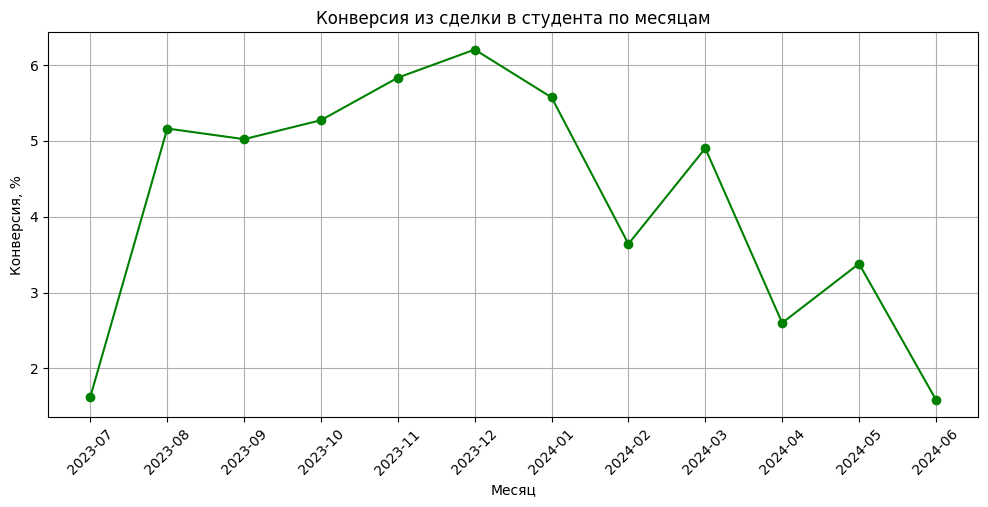

In [51]:
# #График конверсии 
# Здесь мы смотрим не просто количество студентов, а эффективность обработки лидов.
# Если сделок много, но конверсия падает, значит проблема может быть не в количестве заявок, а в их качестве или в работе продаж.

plt.figure(figsize=(12, 5))

plt.plot(monthly_analysis["month"], monthly_analysis["student_conversion"], marker="o", color="green")

plt.title("Конверсия из сделки в студента по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Конверсия, %")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Вывод по временным рядам

Временные ряды позволяют сопоставить динамику сделок, студентов, звонков и рекламных расходов.

Если рост расходов и звонков сопровождается ростом сделок и студентов, это говорит о согласованной работе маркетинга и продаж.  
Если расходы или звонки растут, но количество студентов не увеличивается, это может указывать на проблему в качестве лидов, обработке заявок или конверсии отдела продаж.

Динамика конверсии в студента показывает, насколько эффективно потенциальные сделки превращаются в фактических студентов в разные месяцы.

# Деньги: полученные и потенциально недополученные

### Основная логика по деньгам следующая - реальная выручка считается только по студентам, то есть где is_student == True.

In [53]:
# Проверяем числовой формат денежных столбцов, а именно еще раз приводим денежные столбцы к числовому формату.
# Это нужно, чтобы Python мог корректно считать суммы, средние значения и строить графики.
money_columns = ["initial_amount_paid", "offer_total_amount"]
for col in money_columns:
    analytics_base[col] = pd.to_numeric(analytics_base[col], errors="coerce")

In [54]:
# Делим данные на две группы:
# students — реальные студенты, то есть наши покупатели.
# not_students — лиды, которые не стали студентами.
students = analytics_base[analytics_base["is_student"] == True].copy()
not_students = analytics_base[analytics_base["is_student"] == False].copy()

In [59]:
# Это общая финансовая информация по бизнесу: сколько лидов, сколько студентов, сколько денег получили, 
# какой средний платеж и сколько денег потенциально могли получить от тех, кто не купил..

financial_summary = pd.DataFrame({
    "metric": [
        "Всего сделок / лидов",
        "Количество студентов",
        "Конверсия в студента, %",
        "Полученная выручка",
        "Средний первый платеж",
        "Медианный первый платеж",
        "Студенты без указанной суммы оплаты",
        "Потенциальная сумма по некупившим лидам"],
    "value": [
        len(analytics_base),
        len(students),
        round(len(students) / len(analytics_base) * 100, 2),
        students["initial_amount_paid"].sum(),
        round(students["initial_amount_paid"].mean(), 2),
        round(students["initial_amount_paid"].median(), 2),
        students["initial_amount_paid"].isna().sum(),
        not_students["offer_total_amount"].sum()]})
financial_summary

,metric,value
0,Всего сделок / лидов,19824.00
1,Количество студентов,840.00
2,"Конверсия в студента, %",4.24
3,Полученная выручка,950350.00
4,Средний первый платеж,1131.37
5,Медианный первый платеж,1000.00
6,Студенты без указанной суммы оплаты,0.00
7,Потенциальная сумма по некупившим лидам,23103910.00


#### Выручка во времени

In [60]:
# Для выручки используем closing_date, так как по FAQ это дата поступления денег
# Смотрим, в какие месяцы школа реально получила деньги.
# Это поможет увидеть сезонность: например, есть ли месяцы, когда студентов и выручки больше.
    
students["revenue_month"] = (students["closing_date"].dt.to_period("M").astype(str))

revenue_monthly = (students.groupby("revenue_month").agg(
        students_count=("id", "count"),
        revenue=("initial_amount_paid", "sum"),
        avg_payment=("initial_amount_paid", "mean"),
        median_payment=("initial_amount_paid", "median")).reset_index())

revenue_monthly["avg_payment"] = revenue_monthly["avg_payment"].round(2)
revenue_monthly["median_payment"] = revenue_monthly["median_payment"].round(2)

revenue_monthly

,revenue_month,students_count,revenue,avg_payment,median_payment
0,2023-07,2,2000.0,1000.00,1000.0
1,2023-08,28,15600.0,557.14,350.0
2,2023-09,28,18950.0,676.79,500.0
3,2023-10,32,30700.0,959.38,1000.0
4,2023-11,50,44400.0,888.00,1000.0
5,2023-12,38,34250.0,901.32,1000.0
6,2024-01,59,55500.0,940.68,1000.0
7,2024-02,52,55650.0,1070.19,1000.0
8,2024-03,59,58900.0,998.31,1000.0
9,2024-04,75,78000.0,1040.00,1000.0


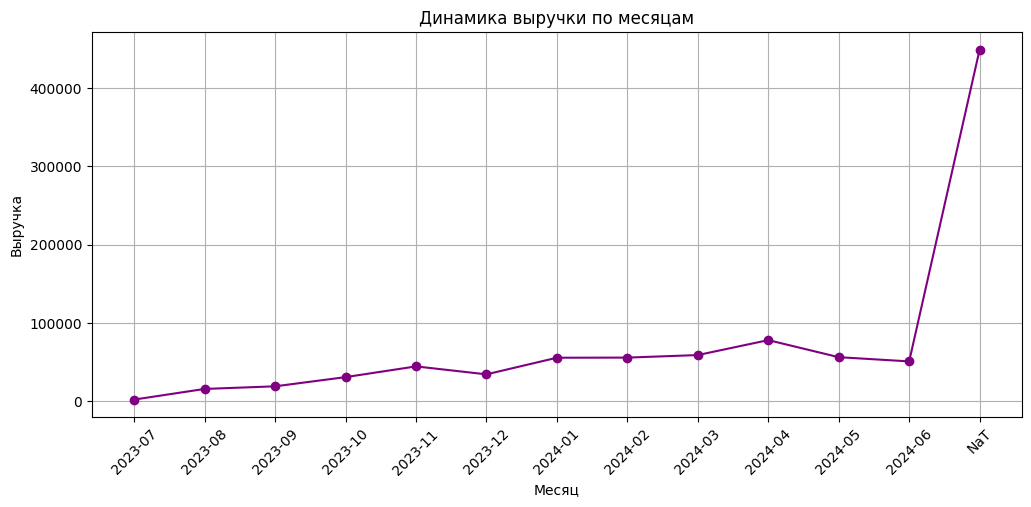

In [170]:
plt.figure(figsize=(12, 5))

plt.plot(revenue_monthly["revenue_month"], revenue_monthly["revenue"], marker="o", color="purple")

plt.title("Динамика выручки по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

#### Средний чек во времени

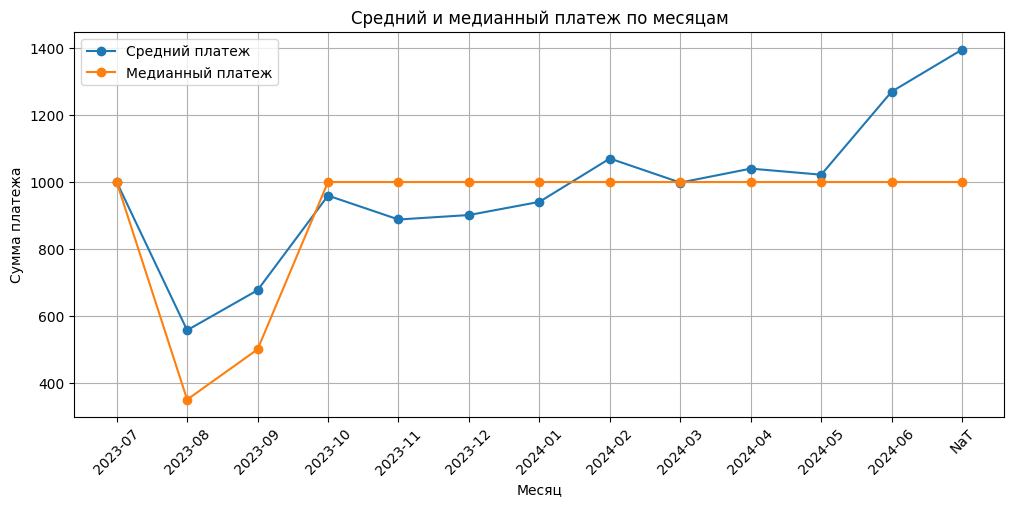

In [61]:
# Средний платеж может искажаться крупными оплатами.
# Поэтому рядом смотрим медиану — она лучше показывает “типичный” платеж студента.
    
plt.figure(figsize=(12, 5))

plt.plot(revenue_monthly["revenue_month"], revenue_monthly["avg_payment"], marker="o", label="Средний платеж")
plt.plot(revenue_monthly["revenue_month"], revenue_monthly["median_payment"], marker="o", label="Медианный платеж")

plt.title("Средний и медианный платеж по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Сумма платежа")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()


#### Деньги по продуктам

In [64]:
# Смотрим какие направления обучения приносят больше денег.

product_money = (students.groupby("product", dropna=False).agg(
        students_count=("id", "count"),
        revenue=("initial_amount_paid", "sum"),
        avg_payment=("initial_amount_paid", "mean"),
        median_payment=("initial_amount_paid", "median")).reset_index())

product_money["avg_payment"] = product_money["avg_payment"].round(2)
product_money["median_payment"] = product_money["median_payment"].round(2)

product_money = product_money.sort_values("revenue", ascending=False)

product_money

,product,students_count,revenue,avg_payment,median_payment
0,Digital Marketing,474,531900.0,1122.15,1000.0
1,UX/UI Design,229,275100.0,1201.31,1000.0
2,Web Developer,137,143350.0,1046.35,1000.0


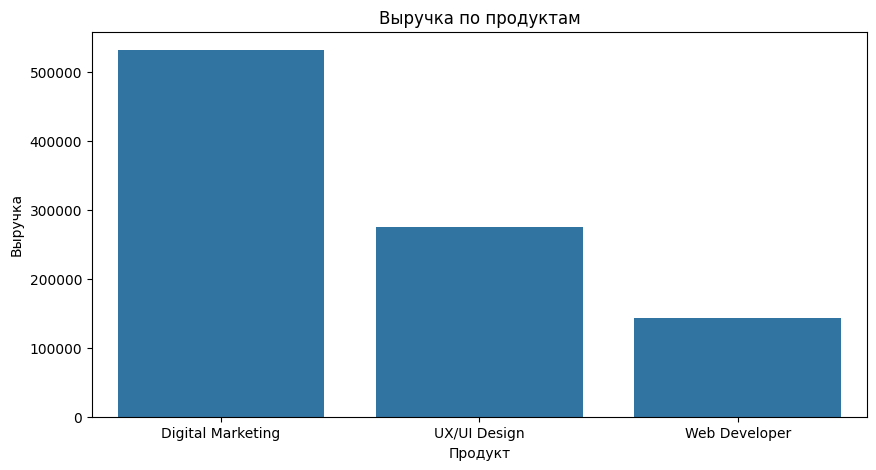

In [67]:
plt.figure(figsize=(10, 5))

sns.barplot(data=product_money, y="revenue", x="product")

plt.title("Выручка по продуктам")
plt.ylabel("Выручка")
plt.xlabel("Продукт")
plt.show()

#### Потенциально недополученные деньги

In [68]:
# Это не настоящая потерянная выручка, а потенциальная сумма предложений по клиентам, которые не стали студентами.
# Но для поиска точки роста это полезно: можно понять, по каким причинам школа теряет больше всего денег.

lost_money_by_reason = (not_students.groupby("lost_reason", dropna=False).agg(
        lost_deals=("id", "count"),
        potential_lost_amount=("offer_total_amount", "sum"),
        avg_offer=("offer_total_amount", "mean")).reset_index())

lost_money_by_reason["avg_offer"] = lost_money_by_reason["avg_offer"].round(2)

lost_money_by_reason = lost_money_by_reason.sort_values("potential_lost_amount", ascending=False)

lost_money_by_reason.head(15)

,lost_reason,lost_deals,potential_lost_amount,avg_offer
20,NaN,4729,6251898.0,9359.13
0,Changed Decision,2139,4630700.0,7835.36
15,Stopped Answering,1573,4585500.0,7772.03
8,Gutstein refusal,169,1485700.0,10038.51
6,Doesn't Answer,4120,1423500.0,2807.69
19,needs time to think,640,1399500.0,9147.06
12,Non target,1757,1172700.0,9020.77
11,Next stream,261,641111.0,7818.43
1,Conditions are not suitable,527,405000.0,4050.00
10,Invalid number,1478,333400.0,4445.33


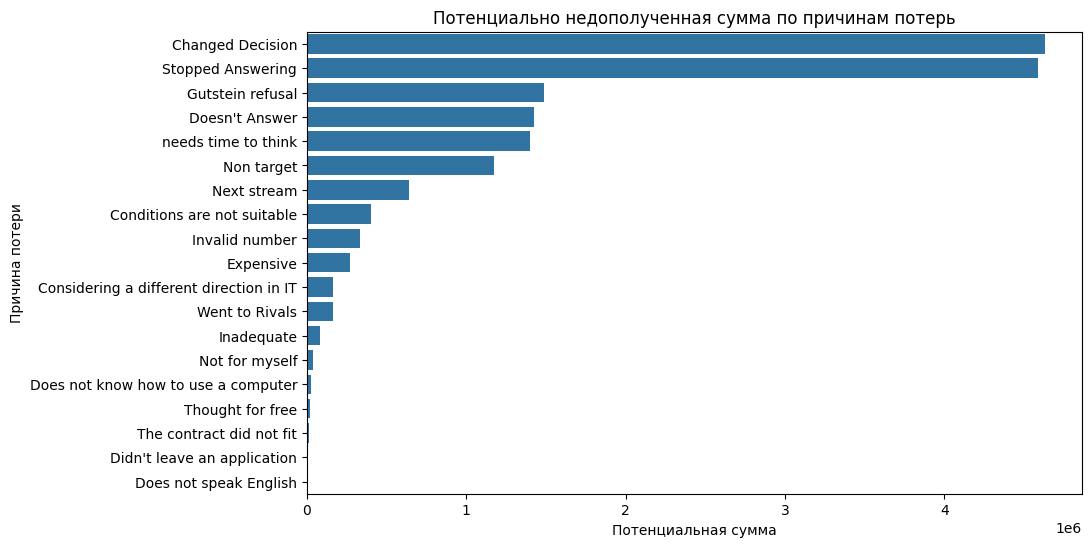

In [71]:
plt.figure(figsize=(10, 6))

sns.barplot(data=lost_money_by_reason.head(20), x="potential_lost_amount", y="lost_reason")

plt.title("Потенциально недополученная сумма по причинам потерь")
plt.xlabel("Потенциальная сумма")
plt.ylabel("Причина потери")
plt.show()

# Вывод по денежным показателям

Реальную выручку считаем только по студентам, так как по условиям проекта факт обучения определяется через `months_of_study`.

Дополнительно была построена динамика выручки по месяцам. Это позволяет увидеть, в какие периоды школа получала больше денег, и проверить возможную сезонность продаж.

Также были рассчитаны средний и медианный платеж. Медиана важна, потому что среднее значение может искажаться отдельными крупными оплатами.

Отдельно была оценена потенциально недополученная сумма по некупившим лидам. Этот показатель не является реальной потерей денег, но помогает найти зоны роста: причины отказов, по которым школа теряет больше всего потенциальной выручки.

# Источники и реклама

#### Обшая цель этого блока - понять, какие source дают больше лидов, студентов и денег. Пока без полноценного ROMI, потому что это уже ближе к юнит-экономике, но базовую эффективность источников уже можно посмотреть.

In [73]:
# Считаем эффективность каждого источника:
# leads_count — сколько лидов пришло из источника.
# students_count — сколько из них стали студентами.
# revenue — сколько денег принесли студенты из этого источника (считаем только по студентам).
# student_conversion — конверсия из лида в студента.
# potential_amount — сумма предложений по всем лидам из источника.

source_analysis = (analytics_base.groupby("source", dropna=False).agg(
        leads_count=("id", "count"),
        students_count=("is_student", "sum"),
        revenue=("initial_amount_paid", lambda x: x[analytics_base.loc[x.index, "is_student"]].sum()),
        avg_student_payment=("initial_amount_paid", lambda x: x[analytics_base.loc[x.index, "is_student"]].mean()),
        potential_amount=("offer_total_amount", lambda x: x[~analytics_base.loc[x.index, "is_student"]].sum())).reset_index())

source_analysis["student_conversion"] = (source_analysis["students_count"] / source_analysis["leads_count"] * 100).round(2)

source_analysis["avg_student_payment"] = source_analysis["avg_student_payment"].round(2)

source_analysis = source_analysis.sort_values("revenue", ascending=False)

source_analysis

,source,leads_count,students_count,revenue,avg_student_payment,potential_amount,student_conversion
2,Facebook Ads,4730,197,225650.0,1145.43,6504798.0,4.16
5,Organic,1499,143,180950.0,1265.38,2811001.0,9.54
3,Google Ads,4115,169,171850.0,1016.86,4395900.0,4.11
7,SMM,1669,88,98750.0,1122.16,2188900.0,5.27
10,Tiktok Ads,2003,56,66150.0,1181.25,1843000.0,2.80
12,Youtube Ads,1618,53,62950.0,1187.74,1568600.0,3.28
8,Telegram posts,993,39,44950.0,1152.56,1254811.0,3.93
11,Webinar,306,26,44850.0,1725.00,454900.0,8.50
0,Bloggers,1074,39,33100.0,848.72,1280000.0,3.63
1,CRM,1456,23,15600.0,678.26,556000.0,1.58


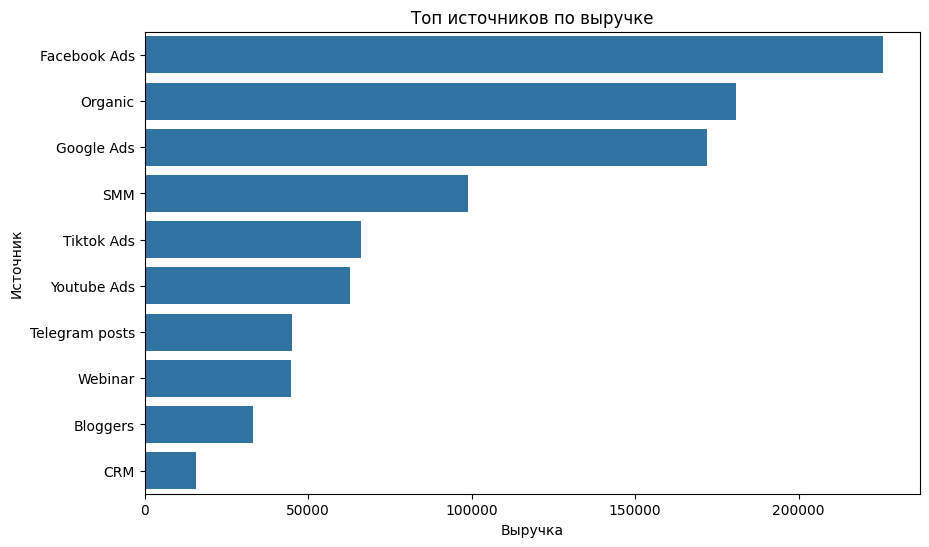

In [74]:
plt.figure(figsize=(10, 6))

sns.barplot(data=source_analysis.head(10), x="revenue", y="source")

plt.title("Топ источников по выручке")
plt.xlabel("Выручка")
plt.ylabel("Источник")
plt.show()

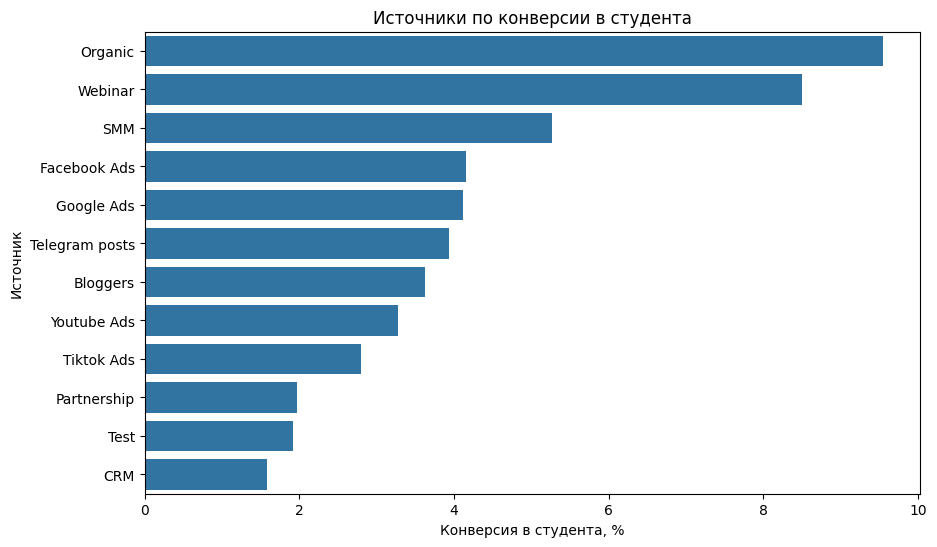

In [77]:
# График по конверсии
# Фильтр leads_count >= 50 нужен, чтобы не делать выводы по источникам, где было слишком мало лидов.
# Например, если источник дал 1 лида и он стал студентом, конверсия будет 100%, но это не значит, что источник действительно лучший

top_sources_by_leads = source_analysis[source_analysis["leads_count"] >= 50].copy()

top_sources_by_leads = top_sources_by_leads.sort_values("student_conversion", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_sources_by_leads.head(15), x="student_conversion", y="source")

plt.title("Источники по конверсии в студента")
plt.xlabel("Конверсия в студента, %")
plt.ylabel("Источник")
plt.show()

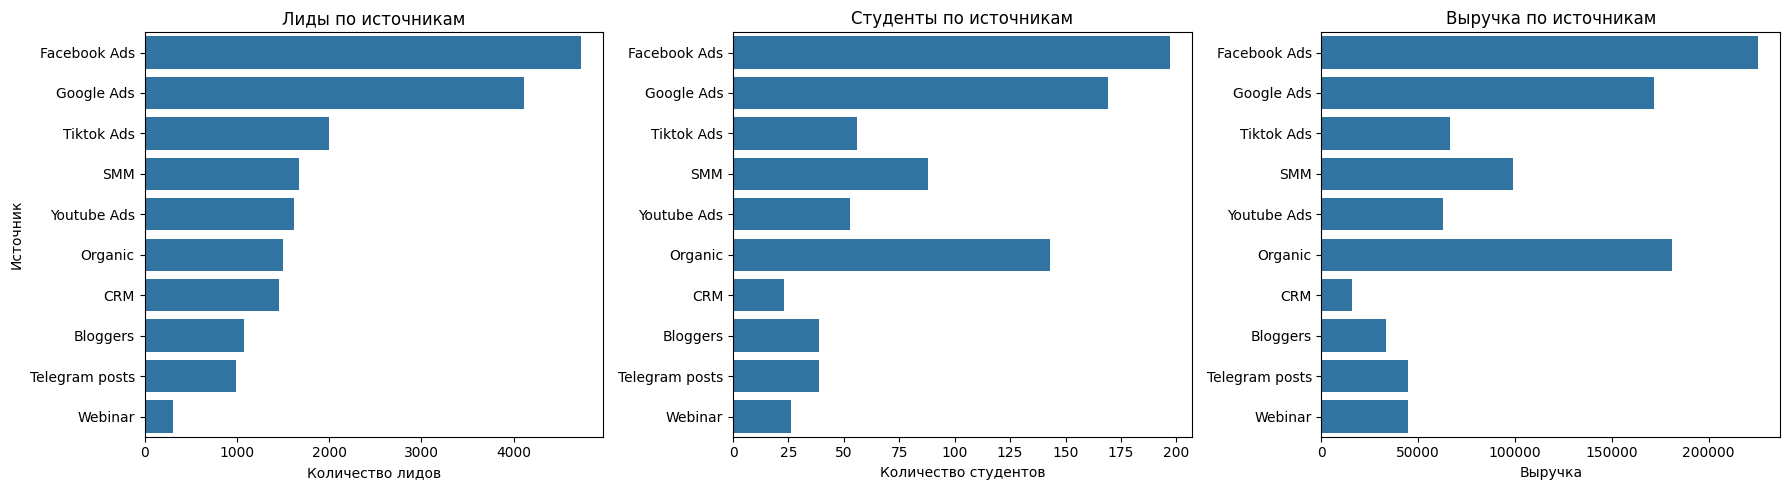

In [79]:
# График: лиды, студенты и выручка рядом

source_top = source_analysis.sort_values("leads_count", ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=source_top, x="leads_count", y="source", ax=axes[0])
axes[0].set_title("Лиды по источникам")
axes[0].set_xlabel("Количество лидов")
axes[0].set_ylabel("Источник")

sns.barplot(data=source_top, x="students_count", y="source", ax=axes[1])
axes[1].set_title("Студенты по источникам")
axes[1].set_xlabel("Количество студентов")
axes[1].set_ylabel("")

sns.barplot(data=source_top, x="revenue", y="source", ax=axes[2])
axes[2].set_title("Выручка по источникам")
axes[2].set_xlabel("Выручка")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

#### Сравнение выручки и расходов по источникам

In [83]:
# По источнику мы видим не только лиды, студенты, выручка, но и расходы, CAC, ROMI.

analytics_base["real_revenue"] = np.where(analytics_base["is_student"], analytics_base["initial_amount_paid"], 0)

source_sales = (analytics_base.groupby("source", dropna=False).agg(leads_count=("id", "count"), students_count=("is_student", "sum"),
        revenue=("real_revenue", "sum")).reset_index())

source_spend = (spend.groupby("source", dropna=False).agg(total_spend=("spend", "sum"), total_clicks=("clicks", "sum"),
        total_impressions=("impressions", "sum")).reset_index())

source_business = source_sales.merge(source_spend, on="source", how="left")

source_business["total_spend"] = source_business["total_spend"].fillna(0)
source_business["total_clicks"] = source_business["total_clicks"].fillna(0)
source_business["total_impressions"] = source_business["total_impressions"].fillna(0)

source_business["lead_to_student_conversion"] = (source_business["students_count"] / source_business["leads_count"] * 100).round(2)

source_business["cac"] = (source_business["total_spend"] / source_business["students_count"].replace(0, np.nan)).round(2)

source_business["romi"] = ((source_business["revenue"] - source_business["total_spend"]) / source_business["total_spend"].replace(0, np.nan) * 100).round(2)

source_business = source_business.sort_values("revenue", ascending=False)

source_business


,source,leads_count,students_count,revenue,total_spend,total_clicks,total_impressions,lead_to_student_conversion,cac,romi
2,Facebook Ads,4730,197,225650.0,33754.72,48133,2850200,4.16,171.34,568.50
5,Organic,1499,143,180950.0,0.00,59089,0,9.54,0.00,NaN
3,Google Ads,4115,169,171850.0,57798.60,248487,32752334,4.11,342.00,197.33
7,SMM,1669,88,98750.0,7269.52,11521,23772,5.27,82.61,1258.41
10,Tiktok Ads,2003,56,66150.0,11985.67,28268,5007212,2.80,214.03,451.91
12,Youtube Ads,1618,53,62950.0,14633.33,59061,8655978,3.28,276.10,330.18
8,Telegram posts,993,39,44950.0,6860.36,16777,705415,3.93,175.91,555.21
11,Webinar,306,26,44850.0,2874.04,3241,301670,8.50,110.54,1460.52
0,Bloggers,1074,39,33100.0,13439.00,14250,738460,3.63,344.59,146.30
1,CRM,1456,23,15600.0,0.00,7995,0,1.58,0.00,NaN


#### Выручка против расходов по источникам

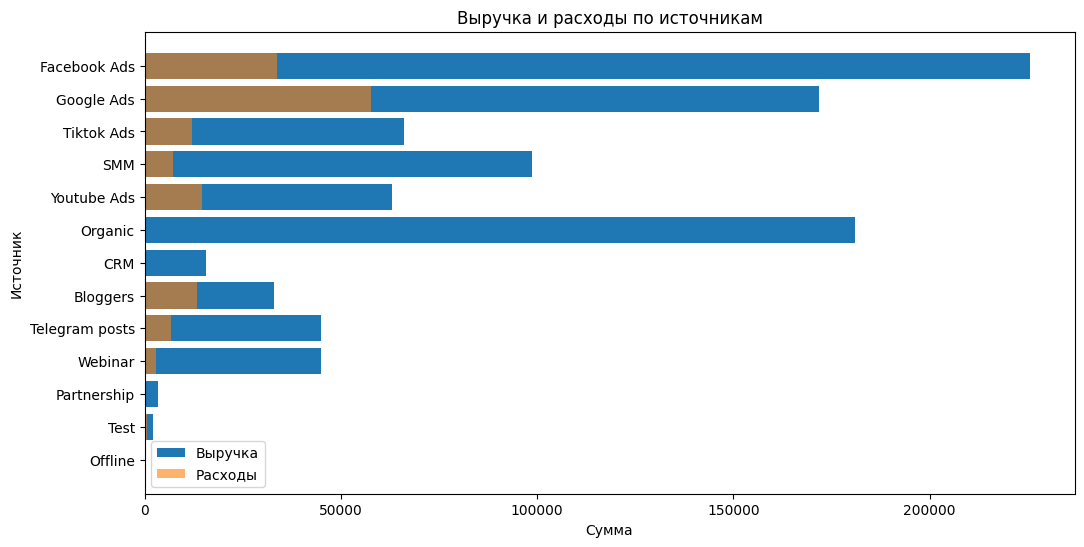

In [85]:
# график показывает, какие источники дают деньги, а какие просто потребляют бюджет.

top_source_business = source_business.sort_values("leads_count", ascending=False).head(15)

plt.figure(figsize=(12, 6))

plt.barh(top_source_business["source"], top_source_business["revenue"], label="Выручка")

plt.barh(top_source_business["source"], top_source_business["total_spend"], label="Расходы", alpha=0.6)

plt.title("Выручка и расходы по источникам")
plt.xlabel("Сумма")
plt.ylabel("Источник")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

#### Анализ кампаний

In [93]:
# Берем только 15 рекламных компаний (их очень много и не все дают номальный эффект), чтобы посмотреть показатели по ним, сортируем по ЛИДАМ.
campaign_sales = (analytics_base.groupby(["source", "campaign"], dropna=False).agg(
        leads_count=("id", "count"),
        students_count=("is_student", "sum"),
        revenue=("real_revenue", "sum")).reset_index())

campaign_spend = (spend.groupby(["source", "campaign"], dropna=False).agg(
        total_spend=("spend", "sum"),
        total_clicks=("clicks", "sum"),
        total_impressions=("impressions", "sum")).reset_index())

campaign_business = campaign_sales.merge(campaign_spend, on=["source", "campaign"], how="left")

campaign_business[["total_spend", "total_clicks", "total_impressions"]] = (campaign_business[["total_spend", "total_clicks", "total_impressions"]].fillna(0))

campaign_business["conversion"] = (campaign_business["students_count"] / campaign_business["leads_count"] * 100).round(2)

campaign_business["cac"] = (campaign_business["total_spend"] / campaign_business["students_count"].replace(0, np.nan)).round(2)

campaign_business["romi"] = ((campaign_business["revenue"] - campaign_business["total_spend"]) / campaign_business["total_spend"].replace(0, np.nan) * 100).round(2)

campaign_business = campaign_business.sort_values("leads_count", ascending=False)

campaign_business.head(15)

,source,campaign,leads_count,students_count,revenue,total_spend,total_clicks,total_impressions,conversion,cac,romi
138,Google Ads,performancemax_digitalmarkt_ru_DE,2572,109,106000.0,0.00,0.0,0.0,4.24,0.00,NaN
354,Youtube Ads,youtube_shorts_DE,1592,53,62950.0,14149.22,57873.0,8481054.0,3.33,266.97,344.90
309,Tiktok Ads,12.07.2023wide_DE,1546,48,61350.0,9471.52,22768.0,3302301.0,3.10,197.32,547.73
164,Organic,Unknown,1343,125,156150.0,0.00,59089.0,0.0,9.31,0.00,NaN
225,SMM,Unknown,1143,70,72150.0,7269.52,11521.0,23772.0,6.12,103.85,892.50
101,Facebook Ads,02.07.23wide_DE,949,52,63250.0,6913.60,10281.0,594807.0,5.48,132.95,814.86
104,Facebook Ads,04.07.23recentlymoved_DE,736,30,26500.0,4523.31,7611.0,417891.0,4.08,150.78,485.85
103,Facebook Ads,03.07.23women,596,30,31000.0,4219.75,7139.0,348089.0,5.03,140.66,634.64
132,Google Ads,Dis_DE,567,29,23700.0,0.00,0.0,0.0,5.11,0.00,NaN
106,Facebook Ads,07.07.23LAL_DE,531,28,46650.0,4200.37,5813.0,335725.0,5.27,150.01,1010.62


In [100]:
# Топ кампаний по лидам. Данная таблица отвечает на вопрос - какие кампании лучше всего приводят лидов.
campaign_business_by_leads = campaign_business.sort_values("leads_count", ascending=False)


# Топ кампаний по конверсии, но с фильтром по минимальному количеству лидов (берем только кампании, где минимум 30 лидов, чтобы не получилось 1 привел, он стал студентом и конверсия = 100% :) )
# Данная таблица отвечает на вопрос - какие кампании лучше всего превращают лидов в студентов.
campaign_business_by_conversion = (campaign_business[campaign_business["leads_count"] >= 30].sort_values("conversion", ascending=False))


# Топ кампаний по выручке. Таблица отвечает на вопрос - какие кампании принесли больше всего денег?
campaign_business_by_revenue = campaign_business.sort_values("revenue", ascending=False)

In [97]:
campaign_business_by_leads.head(15)

,source,campaign,leads_count,students_count,revenue,total_spend,total_clicks,total_impressions,conversion,cac,romi
138,Google Ads,performancemax_digitalmarkt_ru_DE,2572,109,106000.0,0.00,0.0,0.0,4.24,0.00,NaN
354,Youtube Ads,youtube_shorts_DE,1592,53,62950.0,14149.22,57873.0,8481054.0,3.33,266.97,344.90
309,Tiktok Ads,12.07.2023wide_DE,1546,48,61350.0,9471.52,22768.0,3302301.0,3.10,197.32,547.73
164,Organic,Unknown,1343,125,156150.0,0.00,59089.0,0.0,9.31,0.00,NaN
225,SMM,Unknown,1143,70,72150.0,7269.52,11521.0,23772.0,6.12,103.85,892.50
101,Facebook Ads,02.07.23wide_DE,949,52,63250.0,6913.60,10281.0,594807.0,5.48,132.95,814.86
104,Facebook Ads,04.07.23recentlymoved_DE,736,30,26500.0,4523.31,7611.0,417891.0,4.08,150.78,485.85
103,Facebook Ads,03.07.23women,596,30,31000.0,4219.75,7139.0,348089.0,5.03,140.66,634.64
132,Google Ads,Dis_DE,567,29,23700.0,0.00,0.0,0.0,5.11,0.00,NaN
106,Facebook Ads,07.07.23LAL_DE,531,28,46650.0,4200.37,5813.0,335725.0,5.27,150.01,1010.62


In [98]:
campaign_business_by_conversion.head(15)

,source,campaign,leads_count,students_count,revenue,total_spend,total_clicks,total_impressions,conversion,cac,romi
182,Organic,webinar1604,32,8,10800.0,0.00,0.0,0.0,25.00,0.00,NaN
244,SMM,webinar1604,40,7,7500.0,0.00,0.0,0.0,17.50,0.00,NaN
133,Google Ads,brand_search_eng_DE,161,15,29250.0,3457.82,2244.0,7783.0,9.32,230.52,745.91
164,Organic,Unknown,1343,125,156150.0,0.00,59089.0,0.0,9.31,0.00,NaN
137,Google Ads,gen_analyst_DE,35,3,3000.0,2551.00,942.0,8852.0,8.57,850.33,17.60
278,Telegram posts,karta_DE,30,2,1350.0,0.00,0.0,0.0,6.67,0.00,NaN
302,Test,Unknown,30,2,1200.0,0.00,0.0,0.0,6.67,0.00,NaN
225,SMM,Unknown,1143,70,72150.0,7269.52,11521.0,23772.0,6.12,103.85,892.50
101,Facebook Ads,02.07.23wide_DE,949,52,63250.0,6913.60,10281.0,594807.0,5.48,132.95,814.86
116,Facebook Ads,17.03.24wide_AT,37,2,800.0,1435.24,657.0,106981.0,5.41,717.62,-44.26


In [99]:
campaign_business_by_revenue.head(15)

,source,campaign,leads_count,students_count,revenue,total_spend,total_clicks,total_impressions,conversion,cac,romi
164,Organic,Unknown,1343,125,156150.0,0.00,59089.0,0.0,9.31,0.00,NaN
138,Google Ads,performancemax_digitalmarkt_ru_DE,2572,109,106000.0,0.00,0.0,0.0,4.24,0.00,NaN
225,SMM,Unknown,1143,70,72150.0,7269.52,11521.0,23772.0,6.12,103.85,892.50
101,Facebook Ads,02.07.23wide_DE,949,52,63250.0,6913.60,10281.0,594807.0,5.48,132.95,814.86
354,Youtube Ads,youtube_shorts_DE,1592,53,62950.0,14149.22,57873.0,8481054.0,3.33,266.97,344.90
309,Tiktok Ads,12.07.2023wide_DE,1546,48,61350.0,9471.52,22768.0,3302301.0,3.10,197.32,547.73
106,Facebook Ads,07.07.23LAL_DE,531,28,46650.0,4200.37,5813.0,335725.0,5.27,150.01,1010.62
103,Facebook Ads,03.07.23women,596,30,31000.0,4219.75,7139.0,348089.0,5.03,140.66,634.64
133,Google Ads,brand_search_eng_DE,161,15,29250.0,3457.82,2244.0,7783.0,9.32,230.52,745.91
112,Facebook Ads,12.09.23interests_Uxui_DE,516,26,29100.0,3753.06,6301.0,319463.0,5.04,144.35,675.37


### Вывод по источникам и рекламным кампаниям

В этом блоке были проанализированы источники привлечения не только по количеству лидов, но и по качеству: количеству студентов, конверсии в студента, выручке, расходам, CAC (стоимость привлечения одного клиента, CAC = расходы на рекламу / количество студентов) и ROMI (окупаемость маркетинговых расходов, ROMI = (выручка - расходы на рекламу) / расходы на рекламу * 100).

Важно, что источник с большим количеством лидов не всегда является самым эффективным. Часть источников может давать высокий объем заявок, но низкую конверсию в студентов или слабую окупаемость. Поэтому для оценки источников использовались сразу несколько показателей: объем лидов, количество студентов, выручка, расходы и стоимость привлечения студента.

Отдельно было добавлено сравнение выручки и расходов по источникам. Этот график помогает быстро увидеть, какие источники приносят больше денег, чем требуют рекламного бюджета, а какие могут быть проблемными с точки зрения окупаемости.

Также был проведен анализ рекламных кампаний на уровне `source + campaign`. Это позволяет смотреть не только общий источник, например Google Ads или Facebook, но и конкретные кампании внутри источника. Такой анализ полезен для последующей юнит-экономики, потому что помогает найти кампании с высокой выручкой, хорошей конверсией и приемлемой стоимостью привлечения.

Показатели CAC и ROMI на этом этапе используются как предварительные ориентиры. Более точный расчет юнит-экономики будет выполнен отдельно, но уже сейчас можно выделить источники и кампании, которые требуют более внимательного анализа: с высокими расходами, низкой конверсией или отрицательным ROMI.

Дополнительно рекламные кампании были рассмотрены в трех разрезах:

1. по количеству лидов — чтобы понять, какие кампании дают основной объем заявок;
2. по конверсии в студента — чтобы найти кампании с наиболее качественными лидами;
3. по выручке — чтобы определить кампании, которые принесли больше всего денег.

При анализе конверсии важно учитывать размер выборки. Кампания с небольшим количеством лидов может показывать очень высокую конверсию случайно, поэтому для сравнения по конверсии использовался фильтр по минимальному количеству лидов (мин 30 штук).

Такой подход позволяет разделить три разных вопроса: какие кампании дают объем, какие дают качество, а какие реально приносят деньги.

# Менеджеры

In [101]:
# смотрим не просто кто сколько вел сделок, а кто реально приводит студентов и деньги.
# deals_count — сколько сделок/лидов было у менеджера.
# students_count — сколько из них стали студентами.
# revenue — сколько денег принес менеджер.
# avg_payment — средний платеж студента у менеджера.
# avg_sla — среднее время ответа менеджера на заявку.
# student_conversion — конверсия менеджера из лида в студента.
    
manager_analysis = (analytics_base.groupby("deal_owner_name", dropna=False).agg(
        deals_count=("id", "count"),
        students_count=("is_student", "sum"),
        revenue=("real_revenue", "sum"),
        avg_payment=("real_revenue", lambda x: x[x > 0].mean()),
        avg_sla=("sla", "mean")).reset_index())

manager_analysis["student_conversion"] = (manager_analysis["students_count"] / manager_analysis["deals_count"] * 100).round(2)

manager_analysis["avg_payment"] = manager_analysis["avg_payment"].round(2)
manager_analysis["avg_sla"] = manager_analysis["avg_sla"].round(2)

manager_analysis = manager_analysis.sort_values("revenue", ascending=False)

manager_analysis


,deal_owner_name,deals_count,students_count,revenue,avg_payment,avg_sla,student_conversion
4,Cara Iverson,1034,27,149900.0,5551.85,1096.04,2.61
5,Charlie Davis,2799,148,140750.0,951.01,2184.99,5.29
21,Ulysses Adams,2069,141,126100.0,900.71,1320.34,6.81
17,Paula Underwood,1771,93,100650.0,1082.26,1075.87,5.25
12,Julia Nelson,2086,92,84550.0,919.02,1937.17,4.41
18,Quincy Vincent,1805,65,71900.0,1106.15,1282.45,3.60
2,Ben Hall,1303,46,57700.0,1254.35,1503.90,3.53
16,Oliver Taylor,160,50,50250.0,1005.00,1775.24,31.25
22,Victor Barnes,1187,44,46600.0,1059.09,3051.61,3.71
15,Nina Scott,1218,45,40600.0,902.22,1793.41,3.69


In [104]:
# Дальше сделаем фильтр, чтобы не сравнивать менеджеров с маленьким количеством сделок. Фильтр нужен, чтобы не делать выводы по менеджерам, у которых было слишком мало сделок.
# Например, если у менеджера 2 сделки и 1 студент, конверсия будет 50%, но это не значит, что он объективно лучше остальных.

manager_analysis_filtered = manager_analysis[manager_analysis["deals_count"] >= 30].copy()
manager_analysis_filtered = manager_analysis_filtered.sort_values("student_conversion", ascending=False)
manager_analysis_filtered.head(30)

,deal_owner_name,deals_count,students_count,revenue,avg_payment,avg_sla,student_conversion
16,Oliver Taylor,160,50,50250.0,1005.00,1775.24,31.25
21,Ulysses Adams,2069,141,126100.0,900.71,1320.34,6.81
5,Charlie Davis,2799,148,140750.0,951.01,2184.99,5.29
17,Paula Underwood,1771,93,100650.0,1082.26,1075.87,5.25
13,Kevin Parker,500,26,23450.0,901.92,5639.98,5.20
12,Julia Nelson,2086,92,84550.0,919.02,1937.17,4.41
7,Eva Kent,452,18,20000.0,1111.11,771.38,3.98
22,Victor Barnes,1187,44,46600.0,1059.09,3051.61,3.71
15,Nina Scott,1218,45,40600.0,902.22,1793.41,3.69
18,Quincy Vincent,1805,65,71900.0,1106.15,1282.45,3.60


#### График: сделки, студенты, выручка

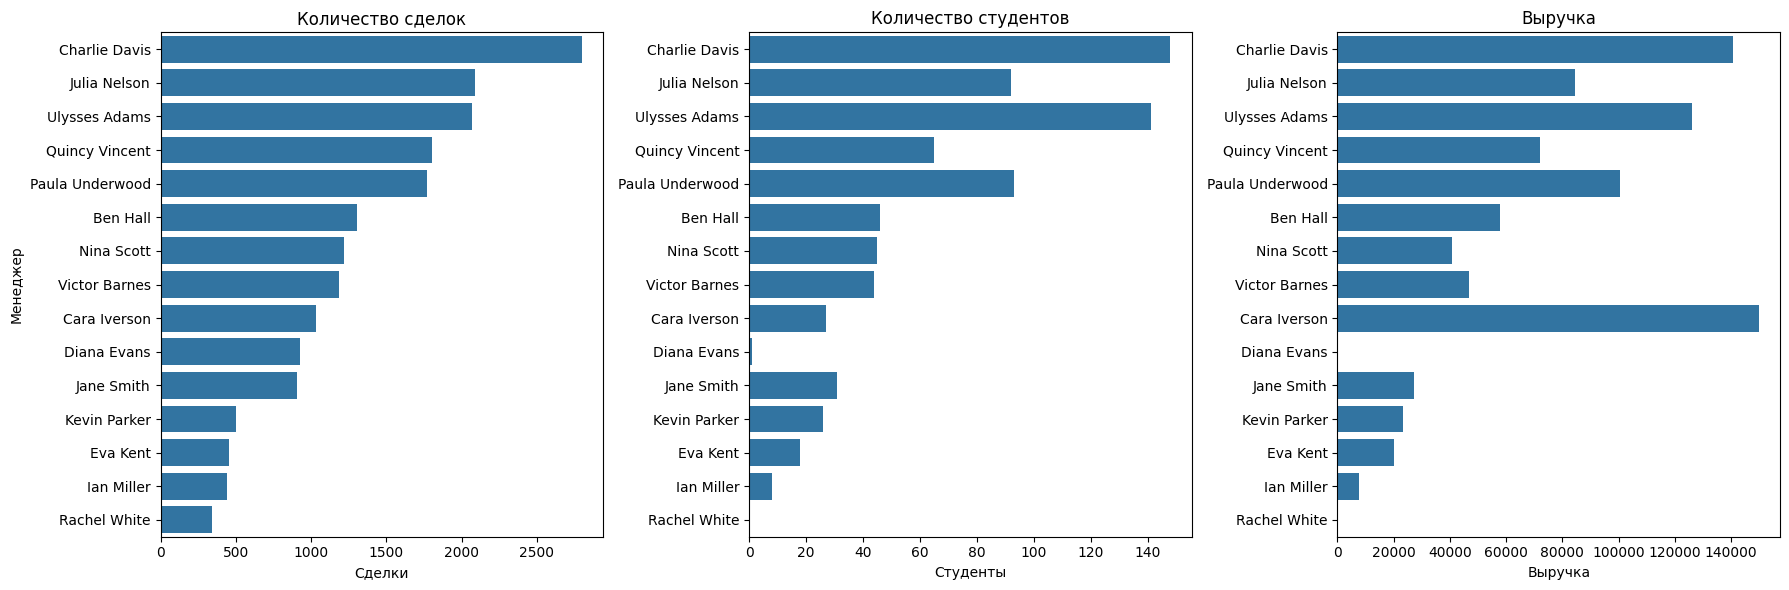

In [105]:
top_managers = manager_analysis.sort_values("deals_count", ascending=False).head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=top_managers, x="deals_count", y="deal_owner_name", ax=axes[0])
axes[0].set_title("Количество сделок")
axes[0].set_xlabel("Сделки")
axes[0].set_ylabel("Менеджер")

sns.barplot(data=top_managers, x="students_count", y="deal_owner_name", ax=axes[1])
axes[1].set_title("Количество студентов")
axes[1].set_xlabel("Студенты")
axes[1].set_ylabel("")

sns.barplot(data=top_managers, x="revenue", y="deal_owner_name", ax=axes[2])
axes[2].set_title("Выручка")
axes[2].set_xlabel("Выручка")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

#### График: конверсия менеджеров

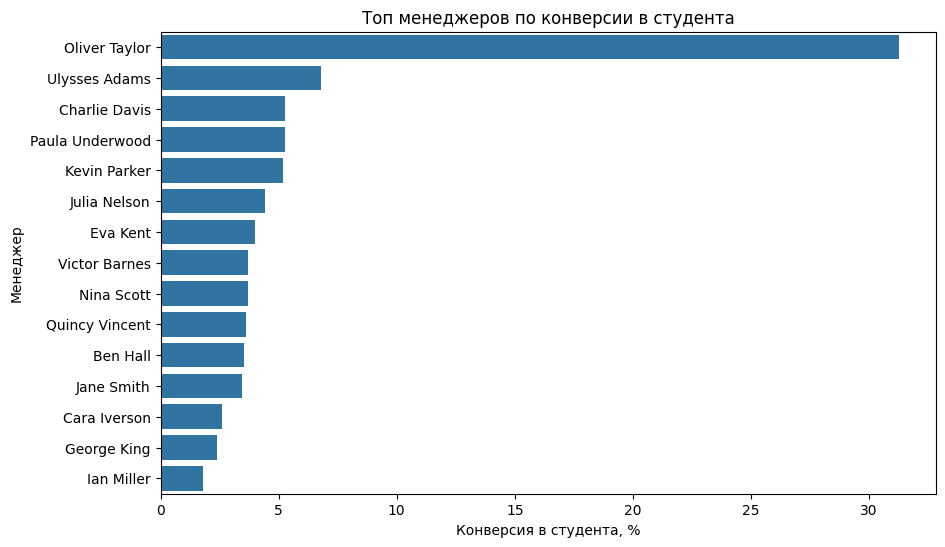

In [106]:
top_managers_by_conversion = (manager_analysis[manager_analysis["deals_count"] >= 30].sort_values("student_conversion", ascending=False).head(15))

plt.figure(figsize=(10, 6))

sns.barplot(data=top_managers_by_conversion, x="student_conversion", y="deal_owner_name")

plt.title("Топ менеджеров по конверсии в студента")
plt.xlabel("Конверсия в студента, %")
plt.ylabel("Менеджер")
plt.show()

#### SLA и конверсия

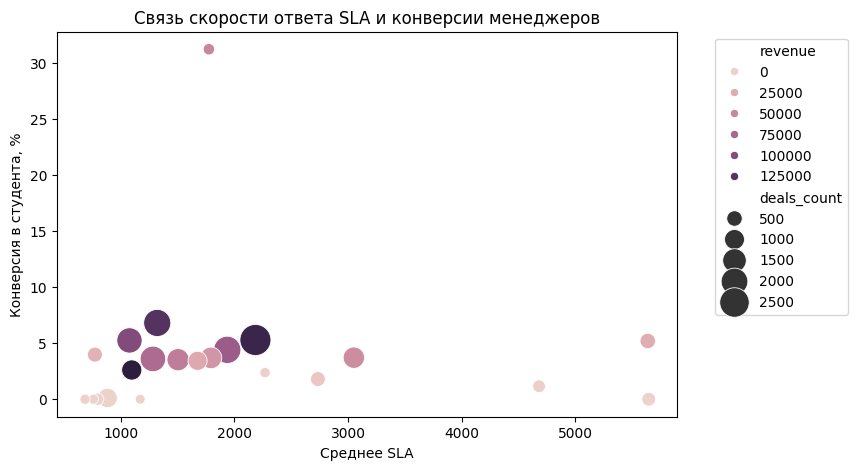

In [107]:
# Этот график помогает проверить гипотезу - влияет ли скорость ответа менеджера на конверсию.
# Если менеджеры с меньшим SLA имеют более высокую конверсию, значит скорость реакции может быть точкой роста.
    
plt.figure(figsize=(8, 5))

sns.scatterplot(data=manager_analysis_filtered, x="avg_sla", y="student_conversion", size="deals_count", hue="revenue", sizes=(50, 500))

plt.title("Связь скорости ответа SLA и конверсии менеджеров")
plt.xlabel("Среднее SLA")
plt.ylabel("Конверсия в студента, %")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

#### Средний чек по менеджеру

In [113]:
# Здесь смотрим менеджеров не по общей выручке, а по среднему платежу одного студента.
# Это помогает понять, кто приводит студентов с более высоким чеком.

manager_avg_check = (manager_analysis[manager_analysis["students_count"] > 0][[
        "deal_owner_name",
        "deals_count",
        "students_count",
        "revenue",
        "avg_student_payment"]].sort_values("avg_student_payment", ascending=False))

manager_avg_check.head(15)

,deal_owner_name,deals_count,students_count,revenue,avg_student_payment
4,Cara Iverson,1034,27,149900.0,5551.85
2,Ben Hall,1303,46,57700.0,1254.35
7,Eva Kent,452,18,20000.0,1111.11
18,Quincy Vincent,1805,65,71900.0,1106.15
17,Paula Underwood,1771,93,100650.0,1082.26
22,Victor Barnes,1187,44,46600.0,1059.09
16,Oliver Taylor,160,50,50250.0,1005.00
5,Charlie Davis,2799,148,140750.0,951.01
9,Ian Miller,444,8,7550.0,943.75
12,Julia Nelson,2086,92,84550.0,919.02


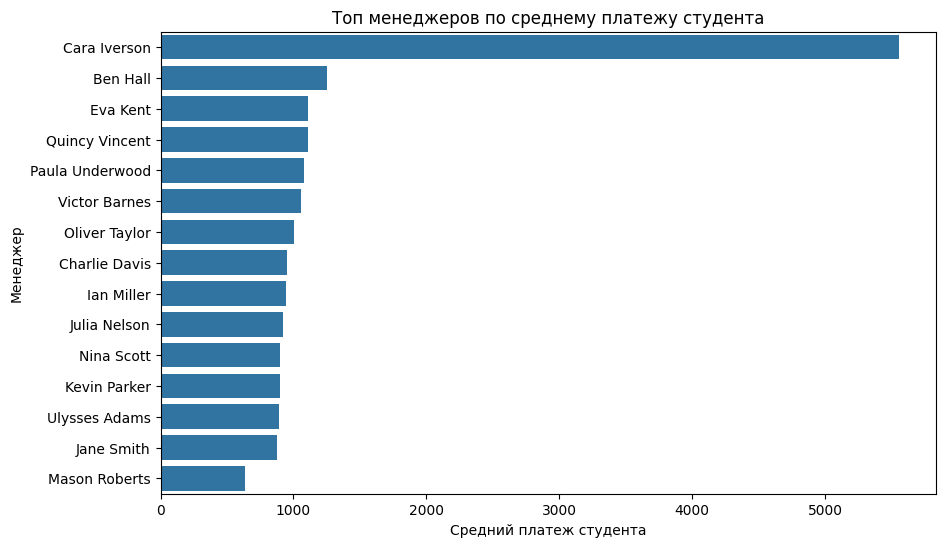

In [114]:
top_manager_avg_check = manager_avg_check.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_manager_avg_check, x="avg_student_payment", y="deal_owner_name")

plt.title("Топ менеджеров по среднему платежу студента")
plt.xlabel("Средний платеж студента")
plt.ylabel("Менеджер")
plt.show()

#### Проблемные сделки по менеджерам

In [115]:
# Смотрим случаи, где клиент считается студентом, но сумма оплаты пустая или равна 0. Это проверка качества данных и работы с CRM.
# Если студент есть, но сумма оплаты не указана или равна 0, значит по такой сделке нельзя корректно посчитать выручку.

problem_deals_by_manager = (analytics_base[(analytics_base["is_student"] == True) & (analytics_base["initial_amount_paid"].isna()
            | (analytics_base["initial_amount_paid"] == 0))].groupby("deal_owner_name", dropna=False).agg(problem_students=("id", "count"))
    .reset_index().sort_values("problem_students", ascending=False))

problem_deals_by_manager

,deal_owner_name,problem_students
0,Ulysses Adams,1


In [117]:
problem_student_deals = analytics_base[(analytics_base["is_student"] == True) & (analytics_base["initial_amount_paid"].isna()
                        | (analytics_base["initial_amount_paid"] == 0))].copy()

problem_student_deals[[
    "id",
    "deal_owner_name",
    "stage",
    "months_of_study",
    "initial_amount_paid",
    "offer_total_amount",
    "product",
    "source"]].head(20)

,id,deal_owner_name,stage,months_of_study,initial_amount_paid,offer_total_amount,product,source
624,5805028000003130171,Ulysses Adams,Payment Done,11.0,0.0,0.0,Digital Marketing,Facebook Ads


# Вывод по менеджерам

Менеджеры были проанализированы по количеству сделок, количеству студентов, выручке, среднему платежу, конверсии в студента и среднему SLA.

Важно сравнивать менеджеров не только по объему сделок, но и по качеству их обработки. Менеджер может вести много сделок, но иметь низкую конверсию. И наоборот, менеджер с меньшим количеством сделок может показывать более высокое качество работы.

Для корректного сравнения конверсии использовался фильтр по минимальному количеству сделок. Это позволяет не делать выводы по менеджерам с очень маленьким колличеством клиентов.

Также была проверена связь между SLA и конверсией. Если менеджеры с меньшим временем ответа показывают более высокую конверсию, это может говорить о том, что скорость обработки заявки влияет на результат продаж.

Дополнительно был рассчитан средний платеж студента по каждому менеджеру. Это позволяет смотреть не только на общий объем выручки, но и на качество закрытых сделок с точки зрения среднего чека.

Также были отдельно выделены проблемные сделки: случаи, когда клиент считается студентом, но сумма первого платежа отсутствует или равна нулю. Такие строки важны для контроля качества данных, потому что они влияют на расчет выручки, среднего чека и дальнейшую юнит-экономику.

# Звонки
Главная задача: проверить, отличаются ли клиенты-студенты от не студентов по звонкам.
То есть смотрим:
- кому чаще звонили;
- у кого больше успешных звонков;
- влияет ли количество звонков на вероятность стать студентом;
- есть ли связь между длительностью звонков и результатом.

In [118]:
# Если у клиента не было звонков или звонки не связались с contact_id, после объединения там могли быть пропуски.
# Для анализа звонков такие пропуски логично считать нулями.
call_columns = ["total_calls","successful_calls", "avg_call_duration_sec", "total_call_duration_sec"]

analytics_base[call_columns] = analytics_base[call_columns].fillna(0)

#### Звонки: студенты VS не студентов

In [120]:
# Сравниваем студентов и не студентов по звонкам. Если у студентов в среднем больше успешных звонков или выше длительность разговора, это может быть важным фактором продаж.
calls_student_comparison = (analytics_base.groupby("is_student").agg(
        deals_count=("id", "count"),
        avg_total_calls=("total_calls", "mean"),
        median_total_calls=("total_calls", "median"),
        avg_successful_calls=("successful_calls", "mean"),
        median_successful_calls=("successful_calls", "median"),
        avg_call_duration_sec=("avg_call_duration_sec", "mean"),
        median_call_duration_sec=("avg_call_duration_sec", "median")).reset_index())

calls_student_comparison

,is_student,deals_count,avg_total_calls,median_total_calls,avg_successful_calls,median_successful_calls,avg_call_duration_sec,median_call_duration_sec
0,False,18984,5.365729,4.0,3.299989,2.0,171.826351,88.000000
1,True,840,12.480952,10.0,8.614286,7.0,290.496863,246.285714


#### График сравнения по звонкам

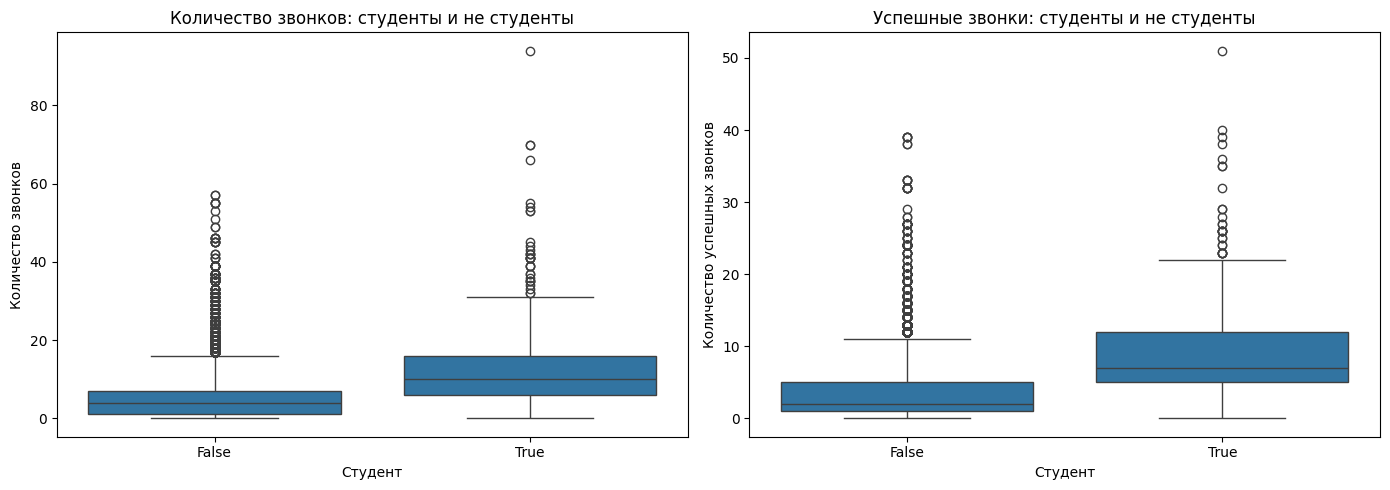

In [121]:
# Boxplot помогает увидеть не только среднее, но и разброс значений. Если у студентов усы выше, значит с ними обычно было больше звонков или успешных звонков.
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=analytics_base, x="is_student", y="total_calls", ax=axes[0])
axes[0].set_title("Количество звонков: студенты и не студенты")
axes[0].set_xlabel("Студент")
axes[0].set_ylabel("Количество звонков")

sns.boxplot(data=analytics_base, x="is_student", y="successful_calls", ax=axes[1])
axes[1].set_title("Успешные звонки: студенты и не студенты")
axes[1].set_xlabel("Студент")
axes[1].set_ylabel("Количество успешных звонков")

plt.tight_layout()
plt.show()

#### Конверсия в зависимости от количества звонков

In [122]:
# Здесь мы делим клиентов на группы по количеству звонков и смотрим, где выше конверсия в студента.
# Например, можно увидеть - 0 звонков → низкая конверсия, 2-3 звонка → выше, 10+ звонков → может снова падать
# Если после большого количества звонков конверсия не растет, это может означать, что часть лидов “тяжелые” или некачественные.

analytics_base["calls_group"] = pd.cut(analytics_base["total_calls"], bins=[-1, 0, 1, 3, 5, 10, np.inf], labels=[
        "0 звонков",
        "1 звонок",
        "2-3 звонка",
        "4-5 звонков",
        "6-10 звонков",
        "10+ звонков"])

calls_group_analysis = (analytics_base.groupby("calls_group", observed=True).agg(leads_count=("id", "count"), students_count=("is_student", "sum")).reset_index())

calls_group_analysis["student_conversion"] = (calls_group_analysis["students_count"] / calls_group_analysis["leads_count"] * 100).round(2)

calls_group_analysis

,calls_group,leads_count,students_count,student_conversion
0,0 звонков,2583,24,0.93
1,1 звонок,2340,10,0.43
2,2-3 звонка,3816,38,1.00
3,4-5 звонков,3374,105,3.11
4,6-10 звонков,4745,261,5.50
5,10+ звонков,2966,402,13.55


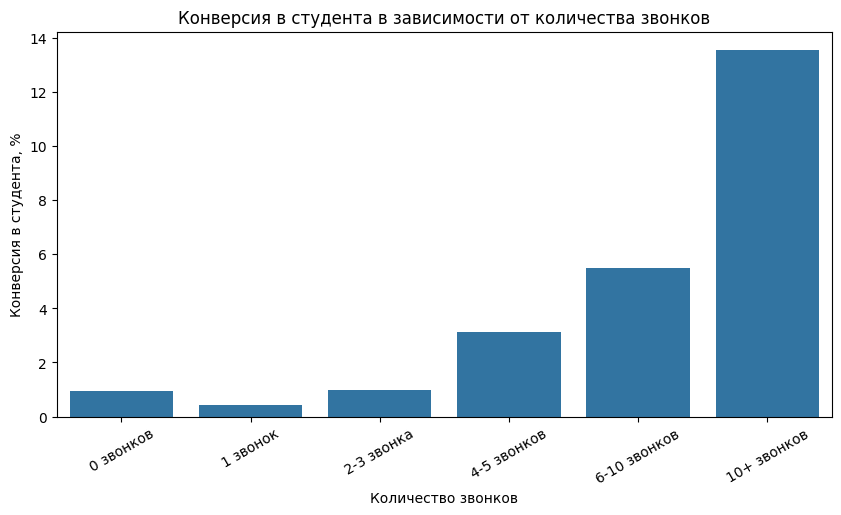

In [123]:
plt.figure(figsize=(10, 5))

sns.barplot(data=calls_group_analysis, x="calls_group", y="student_conversion")

plt.title("Конверсия в студента в зависимости от количества звонков")
plt.xlabel("Количество звонков")
plt.ylabel("Конверсия в студента, %")
plt.xticks(rotation=30)
plt.show()

#### Успешные звонки и конверсия

In [124]:
analytics_base["successful_calls_group"] = pd.cut(analytics_base["successful_calls"],
    bins=[-1, 0, 1, 3, 5, np.inf],labels=[
        "0 успешных",
        "1 успешный",
        "2-3 успешных",
        "4-5 успешных",
        "5+ успешных"])

successful_calls_group_analysis = (analytics_base.groupby("successful_calls_group", observed=True).agg(
        leads_count=("id", "count"), students_count=("is_student", "sum")).reset_index())

successful_calls_group_analysis["student_conversion"] = (successful_calls_group_analysis["students_count"]
    / successful_calls_group_analysis["leads_count"] * 100).round(2)

successful_calls_group_analysis

,successful_calls_group,leads_count,students_count,student_conversion
0,0 успешных,4035,32,0.79
1,1 успешный,3631,13,0.36
2,2-3 успешных,4888,89,1.82
3,4-5 успешных,2934,144,4.91
4,5+ успешных,4336,562,12.96


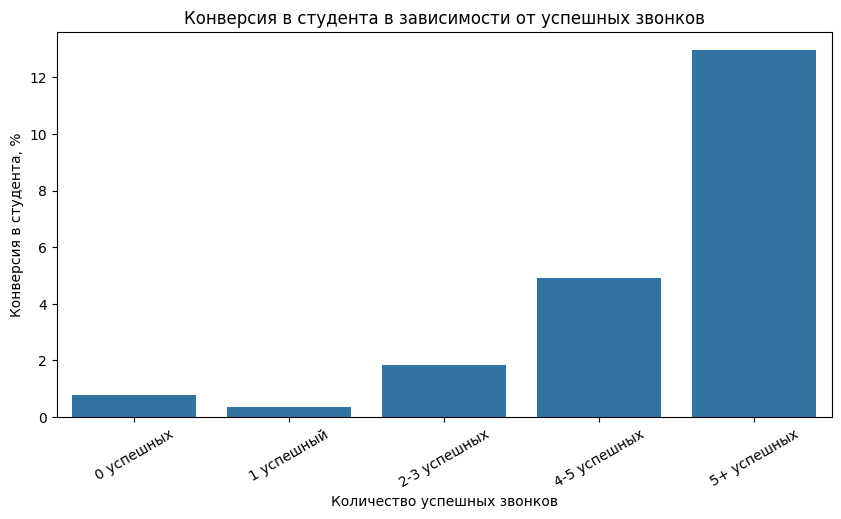

In [126]:
plt.figure(figsize=(10, 5))

sns.barplot(data=successful_calls_group_analysis, x="successful_calls_group", y="student_conversion")

plt.title("Конверсия в студента в зависимости от успешных звонков")
plt.xlabel("Количество успешных звонков")
plt.ylabel("Конверсия в студента, %")
plt.xticks(rotation=30)
plt.show()

#### Успешный контакт как фактор покупки

In [128]:
# Здесь мы делим клиентов на две группы:
# False — не было успешного звонка;
# True — был хотя бы один успешный звонок.
# И смотрим, отличается ли конверсия в студента.

analytics_base["has_successful_call"] = analytics_base["successful_calls"] > 0

successful_contact_analysis = (analytics_base.groupby("has_successful_call").agg(
        leads_count=("id", "count"),
        students_count=("is_student", "sum"),
        revenue=("real_revenue", "sum")).reset_index())

successful_contact_analysis["student_conversion"] = (successful_contact_analysis["students_count"] / successful_contact_analysis["leads_count"] * 100).round(2)

successful_contact_analysis

,has_successful_call,leads_count,students_count,revenue,student_conversion
0,False,4035,32,27600.0,0.79
1,True,15789,808,922750.0,5.12


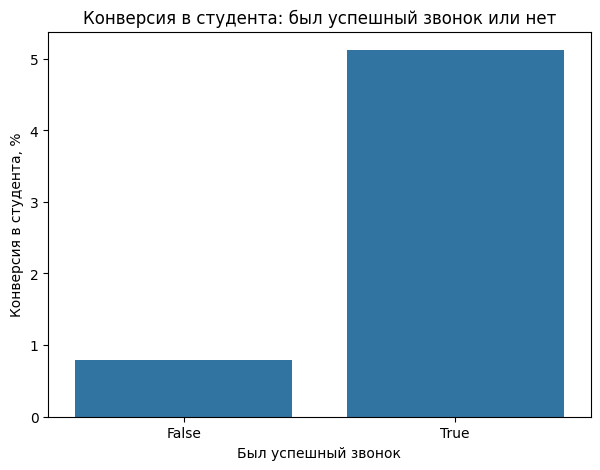

In [129]:
plt.figure(figsize=(7, 5))

sns.barplot(data=successful_contact_analysis, x="has_successful_call", y="student_conversion")

plt.title("Конверсия в студента: был успешный звонок или нет")
plt.xlabel("Был успешный звонок")
plt.ylabel("Конверсия в студента, %")
plt.show()

#### Доля лидов с успешным звонком

In [130]:
# Показывает, насколько хорошо отдел продаж вообще дозванивается до лидов. Если доля успешных звонков низкая, это может быть одной из точек роста.

successful_contact_share = pd.DataFrame({
    "metric": ["Всего лидов", "Лиды с успешным звонком", "Доля лидов с успешным звонком, %"],
    "value": [len(analytics_base), analytics_base["has_successful_call"].sum(), round(analytics_base["has_successful_call"].mean() * 100, 2)]})

successful_contact_share

,metric,value
0,Всего лидов,19824.00
1,Лиды с успешным звонком,15789.00
2,"Доля лидов с успешным звонком, %",79.65


# Вывод по звонкам

Звонки были проанализированы на уровне клиента: общее количество звонков, количество успешных звонков и средняя длительность разговора.

Сравнение студентов и не студентов позволяет проверить, отличаются ли реальные покупатели по активности коммуникации. Если у студентов больше успешных звонков или выше средняя длительность разговора, это может говорить о важности качественного контакта с клиентом.

Также была проверена конверсия в студента в зависимости от количества звонков. Такой анализ помогает понять, есть ли группа клиентов, по которым большое количество звонков не приводит к результату.

Отдельно рассмотрены успешные звонки. Этот показатель важнее общего количества звонков, потому что сам факт дозвона обычно лучше отражает реальный контакт менеджера с клиентом.

Дополнительно был рассмотрен успешный звонок как промежуточная метрика между лидом и покупкой. Это важно, потому что до оплаты клиент сначала должен выйти на контакт с менеджером.

Клиенты были разделены на две группы: с успешным звонком и без успешного звонка. Сравнение конверсии между этими группами позволяет проверить, насколько факт дозвона связан с вероятностью стать студентом.

Такой показатель можно использовать как прокси-метрику для будущих гипотез. Например, если улучшить скорость и качество первого контакта, можно ожидать роста успешных звонков, а затем и роста оплат.

# Продукты
Здесь анализируем, какие направления обучения дают больше:
лидов;
студентов;
конверсии;
выручки;
среднего платежа.

In [131]:
# Собираем основную таблицу по продуктам. Она показывает, какие курсы дают больше лидов, студентов, денег и какой средний платеж у студентов.

product_analysis = (analytics_base.groupby("product", dropna=False).agg(
        leads_count=("id", "count"),
        students_count=("is_student", "sum"),
        revenue=("real_revenue", "sum"),
        avg_student_payment=("real_revenue", lambda x: x[x > 0].mean()),
        median_student_payment=("real_revenue", lambda x: x[x > 0].median())).reset_index())

product_analysis["student_conversion"] = (product_analysis["students_count"] / product_analysis["leads_count"] * 100).round(2)

product_analysis["avg_student_payment"] = (product_analysis["avg_student_payment"].round(2))

product_analysis["median_student_payment"] = (product_analysis["median_student_payment"].round(2))

product_analysis = product_analysis.sort_values("revenue", ascending=False)

product_analysis

,product,leads_count,students_count,revenue,avg_student_payment,median_student_payment,student_conversion
1,Digital Marketing,2444,474,531900.0,1124.52,1000.0,19.39
3,UX/UI Design,1216,229,275100.0,1201.31,1000.0,18.83
5,Web Developer,714,137,143350.0,1046.35,1000.0,19.19
0,Data Analytics,1,0,0.0,NaN,NaN,0.00
2,Find yourself in IT,19,0,0.0,NaN,NaN,0.00
4,Unknown,15430,0,0.0,NaN,NaN,0.00


In [139]:
# revenue_share показывает, какую долю всей выручки дает каждый продукт.
# students_share показывает, какую долю студентов дает каждый продукт.
# revenue_per_lead показывает, сколько денег в среднем приносит один лид по продукту. Это очень полезный показатель: продукт может иметь не самую высокую конверсию, но давать больше денег на одного лида.

product_analysis_extended = product_analysis.copy()

product_analysis_extended["revenue_share"] = (product_analysis_extended["revenue"] / product_analysis_extended["revenue"].sum() * 100).round(2)

product_analysis_extended["students_share"] = (product_analysis_extended["students_count"] / product_analysis_extended["students_count"].sum() * 100).round(2)

product_analysis_extended["revenue_per_lead"] = (product_analysis_extended["revenue"] / product_analysis_extended["leads_count"]).round(2)

product_analysis_extended = product_analysis_extended.sort_values("revenue", ascending=False)

product_analysis_extended

,product,leads_count,students_count,revenue,avg_student_payment,median_student_payment,student_conversion,revenue_share,students_share,revenue_per_lead
1,Digital Marketing,2444,474,531900.0,1124.52,1000.0,19.39,55.97,56.43,217.64
3,UX/UI Design,1216,229,275100.0,1201.31,1000.0,18.83,28.95,27.26,226.23
5,Web Developer,714,137,143350.0,1046.35,1000.0,19.19,15.08,16.31,200.77
0,Data Analytics,1,0,0.0,NaN,NaN,0.00,0.00,0.00,0.00
2,Find yourself in IT,19,0,0.0,NaN,NaN,0.00,0.00,0.00,0.00
4,Unknown,15430,0,0.0,NaN,NaN,0.00,0.00,0.00,0.00


#### Графики по продуктам

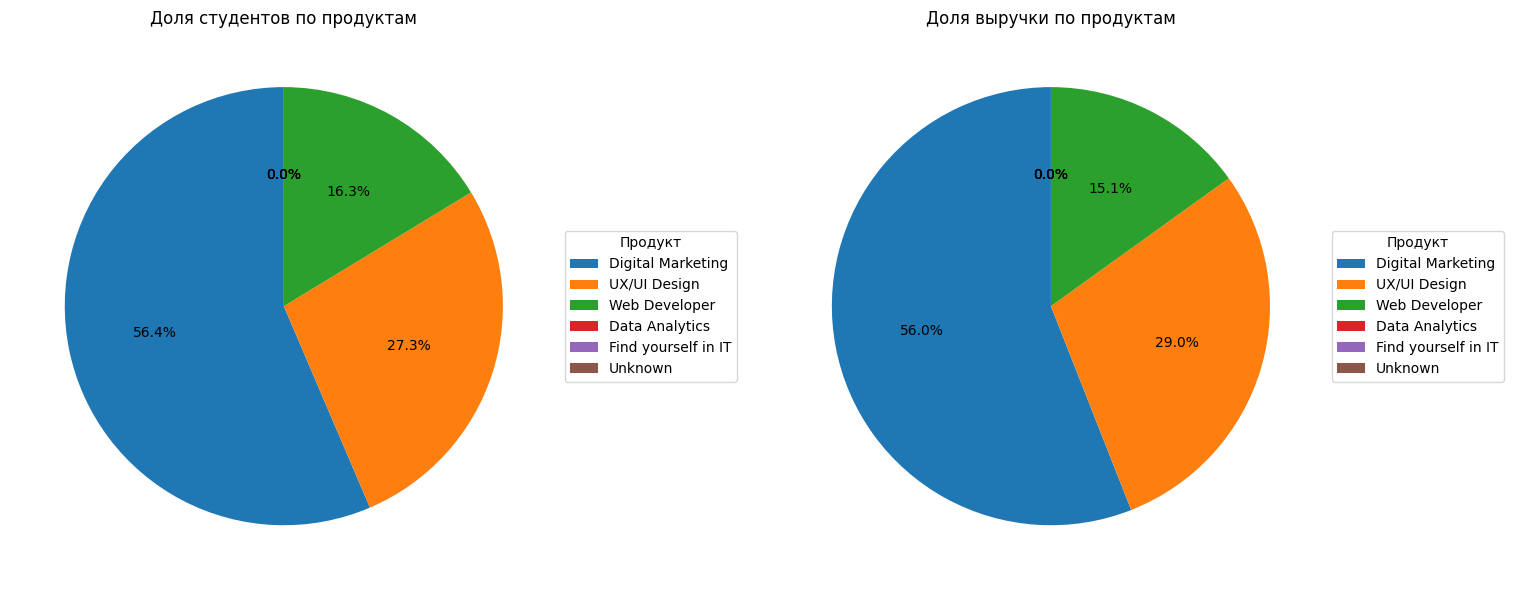

In [141]:
# какую долю всей выручки дает каждый продукт.
# какую долю студентов дает каждый продукт.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wedges_1, texts_1, autotexts_1 = axes[0].pie(product_analysis_extended["students_share"], autopct="%1.1f%%", startangle=90)
axes[0].set_title("Доля студентов по продуктам")
axes[0].legend(wedges_1, product_analysis_extended["product"], title="Продукт", loc="center left", bbox_to_anchor=(1, 0.5))

wedges_2, texts_2, autotexts_2 = axes[1].pie(product_analysis_extended["revenue_share"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Доля выручки по продуктам")
axes[1].legend(wedges_2, product_analysis_extended["product"], title="Продукт", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

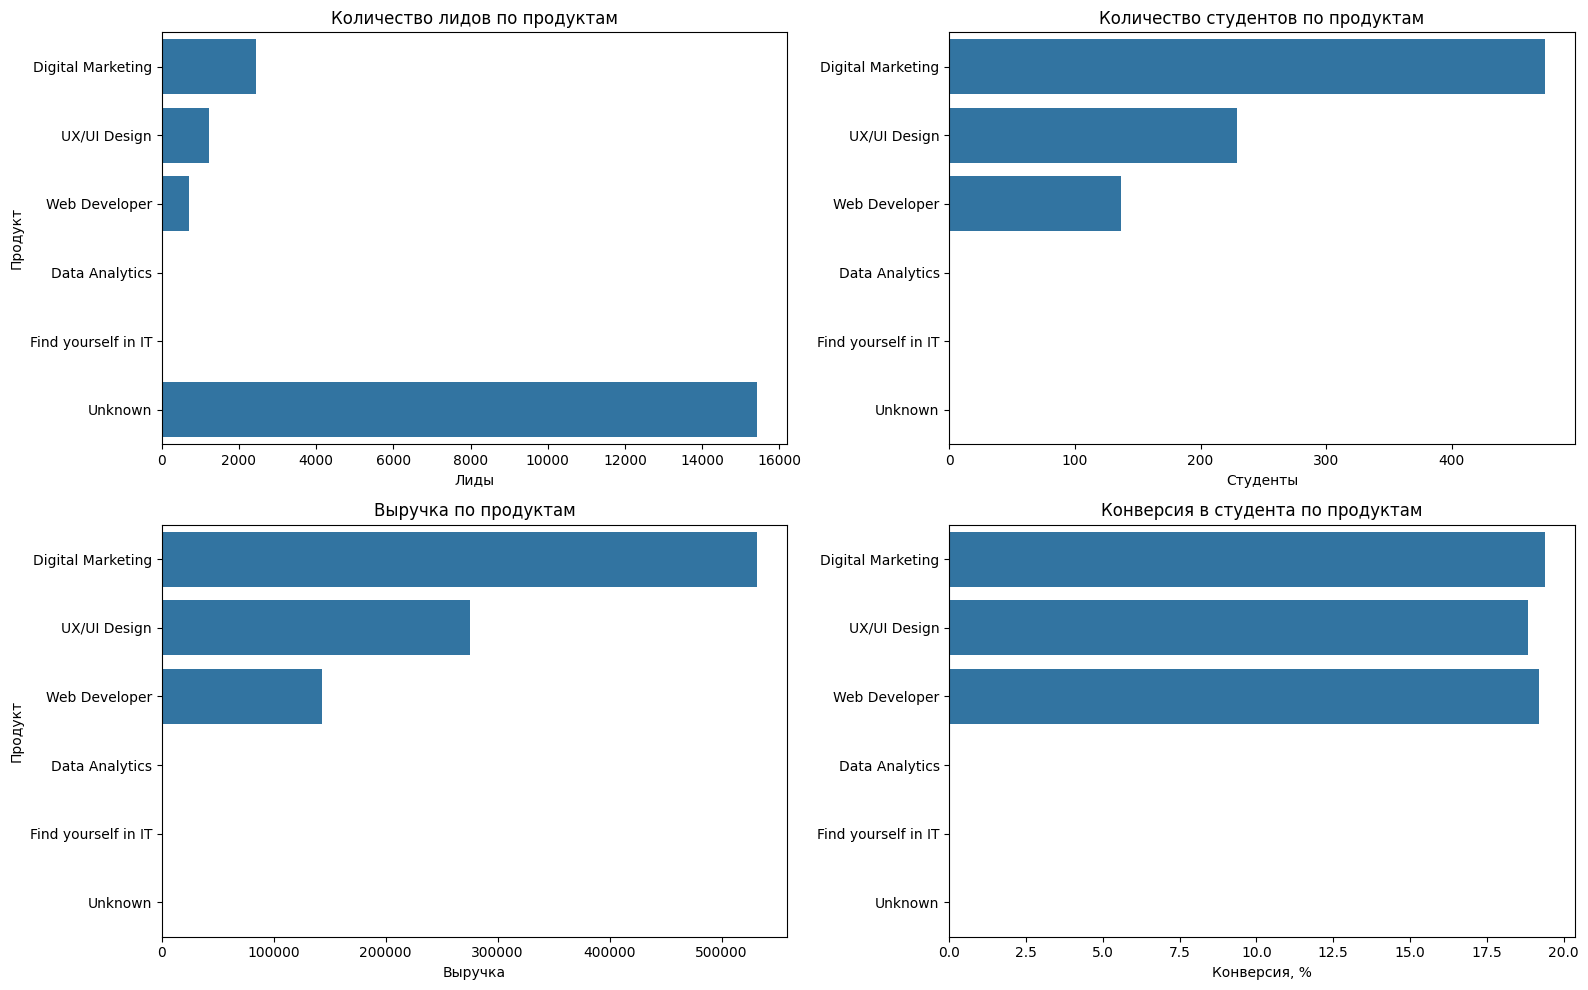

In [132]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=product_analysis, x="leads_count", y="product", ax=axes[0, 0])
axes[0, 0].set_title("Количество лидов по продуктам")
axes[0, 0].set_xlabel("Лиды")
axes[0, 0].set_ylabel("Продукт")

sns.barplot(data=product_analysis, x="students_count", y="product", ax=axes[0, 1])
axes[0, 1].set_title("Количество студентов по продуктам")
axes[0, 1].set_xlabel("Студенты")
axes[0, 1].set_ylabel("")

sns.barplot(data=product_analysis, x="revenue", y="product", ax=axes[1, 0])
axes[1, 0].set_title("Выручка по продуктам")
axes[1, 0].set_xlabel("Выручка")
axes[1, 0].set_ylabel("Продукт")

sns.barplot(data=product_analysis, x="student_conversion", y="product", ax=axes[1, 1])
axes[1, 1].set_title("Конверсия в студента по продуктам")
axes[1, 1].set_xlabel("Конверсия, %")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

#### С учетом того, что у нас только 3 основных продукта, построим графики исключительно для них, чтобы посмотреть общую картину.

In [176]:
# Оставляем только три основных продукта для презентации
main_products = ["Digital Marketing", "UX/UI Design", "Web Developer"]

product_data = analytics_base[analytics_base["product"].isin(main_products)].copy()

# Определяем, какой столбец выручки есть в таблице
if "fair_revenue" in product_data.columns:
    revenue_column = "fair_revenue"
    revenue_title = "Справедливая выручка по продуктам"
else:
    revenue_column = "real_revenue"
    revenue_title = "Выручка по продуктам"

# Собираем показатели по каждому продукту
product_summary = (product_data.groupby("product").agg(leads=("id", "count"), students=("is_student", "sum"), revenue=(revenue_column, "sum"))
    .reindex(main_products).reset_index())

product_summary["conversion"] = (product_summary["students"] / product_summary["leads"] * 100).round(2)

product_summary

,product,leads,students,revenue,conversion
0,Digital Marketing,2444,474,531900.0,19.39
1,UX/UI Design,1216,229,275100.0,18.83
2,Web Developer,714,137,143350.0,19.19


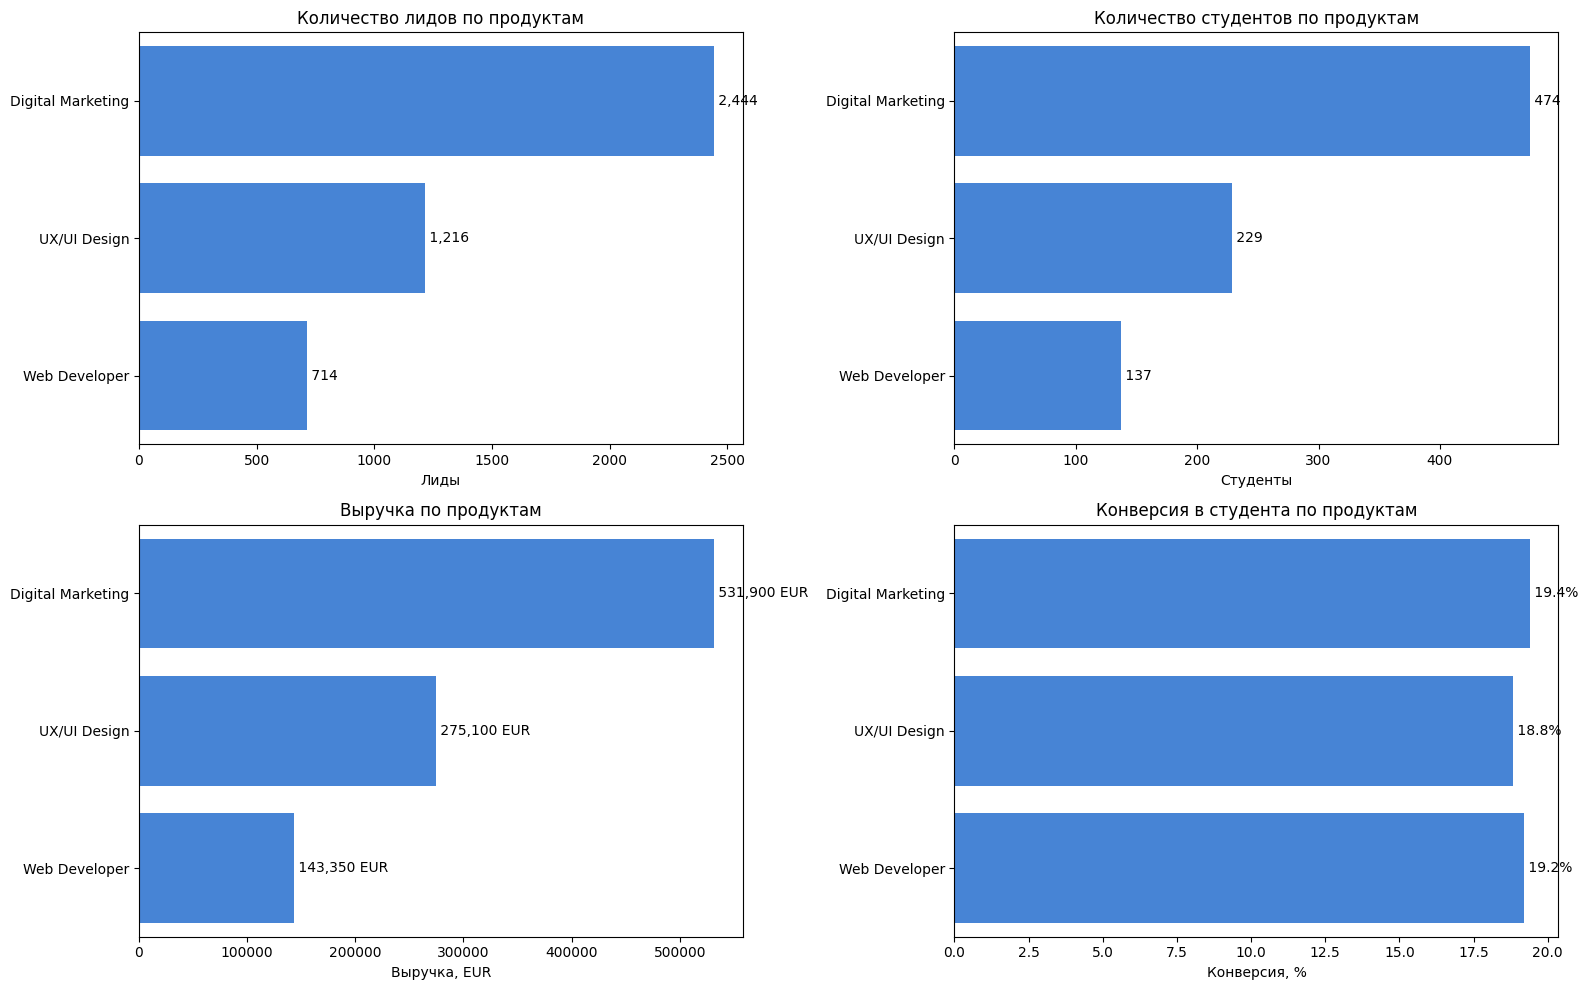

In [177]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

main_color = "#2F80ED"

# 1. Лиды
sns.barplot(data=product_summary, x="leads", y="product", color=main_color, ax=axes[0, 0])

axes[0, 0].set_title("Количество лидов по продуктам")
axes[0, 0].set_xlabel("Лиды")
axes[0, 0].set_ylabel("")

# 2. Студенты
sns.barplot(data=product_summary, x="students", y="product", color=main_color,  ax=axes[0, 1])

axes[0, 1].set_title("Количество студентов по продуктам")
axes[0, 1].set_xlabel("Студенты")
axes[0, 1].set_ylabel("")

# 3. Выручка
sns.barplot(data=product_summary, x="revenue", y="product", color=main_color, ax=axes[1, 0])

axes[1, 0].set_title(revenue_title)
axes[1, 0].set_xlabel("Выручка, EUR")
axes[1, 0].set_ylabel("")

# 4. Конверсия
sns.barplot(data=product_summary, x="conversion", y="product", color=main_color, ax=axes[1, 1])

axes[1, 1].set_title("Конверсия в студента по продуктам")
axes[1, 1].set_xlabel("Конверсия, %")
axes[1, 1].set_ylabel("")

# Подписи значений
for ax, column, suffix, decimals in [(axes[0, 0], "leads", "", 0), (axes[0, 1], "students", "", 0), (axes[1, 0], "revenue", " EUR", 0), (axes[1, 1], "conversion", "%", 1)]:
    for i, value in enumerate(product_summary[column]):
        text = f"{value:,.{decimals}f}{suffix}"
        ax.text(value, i, f" {text}", va="center")

plt.tight_layout()
plt.show()

#### Средний и медианный платеж по продуктам

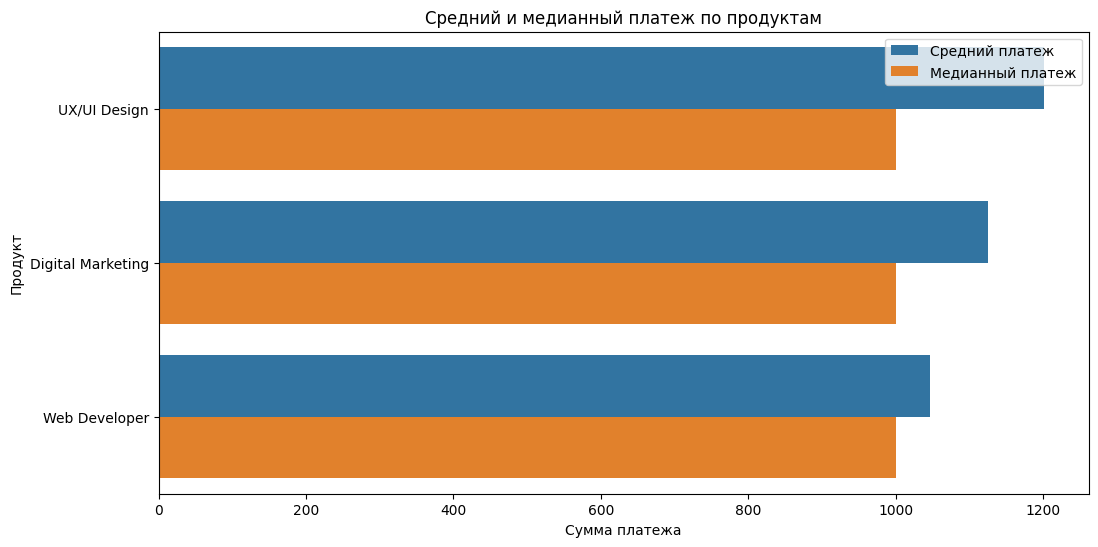

In [137]:
# Средний платеж может быть выше из-за отдельных крупных оплат. Медианный платеж показывает более типичное значение для продукта.
# если средний сильно выше медианы, значит есть отдельные крупные платежи, которые тянут среднее вверх
product_payment_plot = product_payment[["product", "avg_student_payment", "median_student_payment"]].melt(
    id_vars="product",
    value_vars=["avg_student_payment", "median_student_payment"],
    var_name="payment_metric",
    value_name="payment_amount")

payment_metric_names = {"avg_student_payment": "Средний платеж", "median_student_payment": "Медианный платеж"}

product_payment_plot["payment_metric"] = (product_payment_plot["payment_metric"].replace(payment_metric_names))

plt.figure(figsize=(12, 6))

sns.barplot(data=product_payment_plot, x="payment_amount", y="product", hue="payment_metric")

plt.title("Средний и медианный платеж по продуктам")
plt.xlabel("Сумма платежа")
plt.ylabel("Продукт")
plt.legend(title="")
plt.show()

#### Тип обучения

In [134]:
education_analysis = (analytics_base.groupby("education_type", dropna=False).agg(
        leads_count=("id", "count"),
        students_count=("is_student", "sum"),
        revenue=("real_revenue", "sum")).reset_index())

education_analysis["student_conversion"] = (education_analysis["students_count"] / education_analysis["leads_count"] * 100).round(2)

education_analysis = education_analysis.sort_values("revenue", ascending=False)

education_analysis

,education_type,leads_count,students_count,revenue,student_conversion
1,Morning,3563,662,786850.0,18.58
0,Evening,512,171,156500.0,33.40
2,Unknown,15749,7,7000.0,0.04


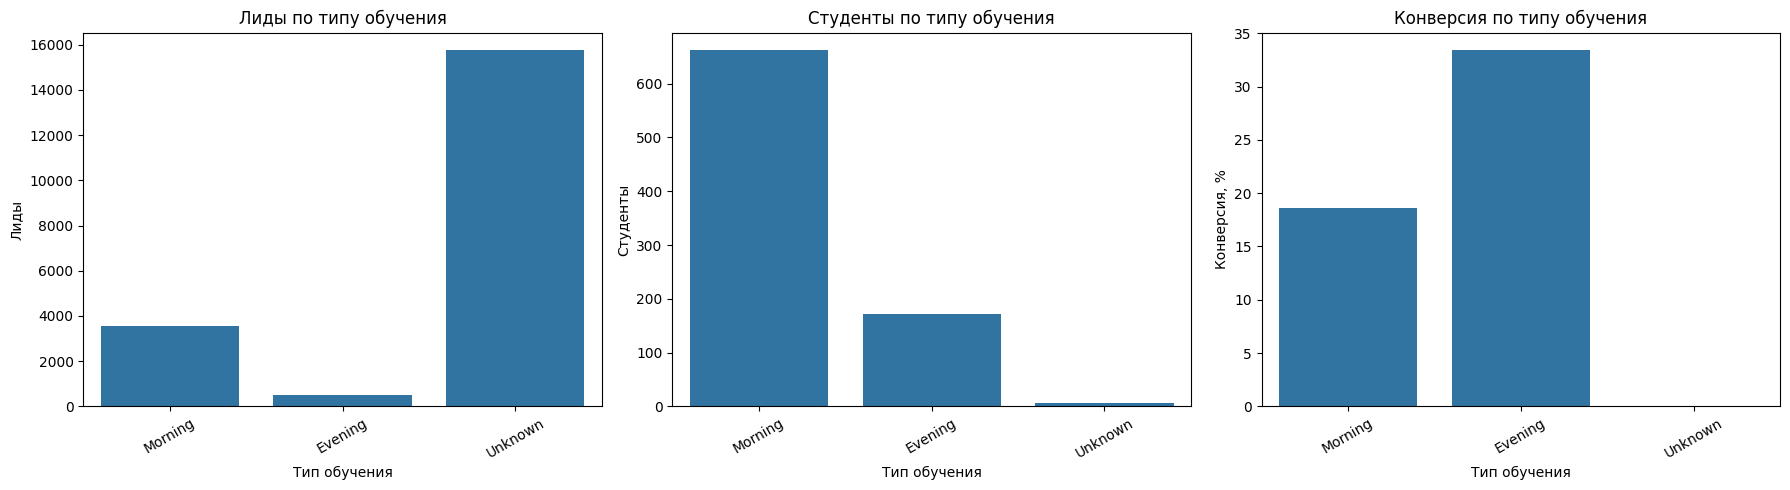

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=education_analysis, x="education_type", y="leads_count", ax=axes[0])
axes[0].set_title("Лиды по типу обучения")
axes[0].set_xlabel("Тип обучения")
axes[0].set_ylabel("Лиды")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=education_analysis, x="education_type", y="students_count", ax=axes[1])
axes[1].set_title("Студенты по типу обучения")
axes[1].set_xlabel("Тип обучения")
axes[1].set_ylabel("Студенты")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=education_analysis, x="education_type", y="student_conversion", ax=axes[2])
axes[2].set_title("Конверсия по типу обучения")
axes[2].set_xlabel("Тип обучения")
axes[2].set_ylabel("Конверсия, %")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### Вывод по продуктам

Продукты были проанализированы по количеству лидов, количеству студентов, конверсии, выручке, среднему и медианному платежу.
Такой анализ помогает понять, какие направления обучения дают основной объем продаж, а какие приносят больше денег за счет более высокого среднего платежа.

Важно сравнивать продукты не только по количеству лидов. Продукт может давать много заявок, но слабую конверсию в студентов. Другой продукт может иметь меньше лидов, но более высокий средний чек или лучшую конверсию.

Так же мы установили какую долю какой продукт занимает по выручке и по студентам.

Также отдельно был рассмотрен тип обучения. Это позволяет понять, какие форматы обучения чаще выбирают клиенты и какие форматы лучше конвертируются в студентов.

# Причины потерь

Здесь анализируем только тех, кто не стал студентом, потому что нас интересует, почему лиды не дошли до покупки.

In [142]:
# Оставляем только не студентов. Студенты для анализа потерь нам не нужны.

lost_deals = analytics_base[analytics_base["is_student"] == False].copy()

In [143]:
# Считаем по каждой причине потери:
# lost_deals_count — сколько сделок потеряно по этой причине.
# potential_lost_amount — потенциальная сумма предложений по этим сделкам.
# lost_deals_share — доля этой причины среди всех потерь.
# potential_lost_amount_share — доля этой причины в потенциально недополученной сумме.
# avg_offer — средний размер предложения.
    
lost_reason_analysis = (lost_deals.groupby("lost_reason", dropna=False).agg(
        lost_deals_count=("id", "count"),
        potential_lost_amount=("offer_total_amount", "sum"),
        avg_offer=("offer_total_amount", "mean")).reset_index())

lost_reason_analysis["lost_deals_share"] = (lost_reason_analysis["lost_deals_count"] / lost_reason_analysis["lost_deals_count"].sum() * 100).round(2)

lost_reason_analysis["potential_lost_amount_share"] = (lost_reason_analysis["potential_lost_amount"] / lost_reason_analysis["potential_lost_amount"].sum() * 100).round(2)

lost_reason_analysis["avg_offer"] = (lost_reason_analysis["avg_offer"].round(2))

lost_reason_analysis = lost_reason_analysis.sort_values("lost_deals_count", ascending=False)

lost_reason_analysis

,lost_reason,lost_deals_count,potential_lost_amount,avg_offer,lost_deals_share,potential_lost_amount_share
20,NaN,4729,6251898.0,9359.13,24.91,27.06
6,Doesn't Answer,4120,1423500.0,2807.69,21.70,6.16
0,Changed Decision,2139,4630700.0,7835.36,11.27,20.04
12,Non target,1757,1172700.0,9020.77,9.26,5.08
15,Stopped Answering,1573,4585500.0,7772.03,8.29,19.85
10,Invalid number,1478,333400.0,4445.33,7.79,1.44
19,needs time to think,640,1399500.0,9147.06,3.37,6.06
7,Expensive,622,272901.0,3066.30,3.28,1.18
1,Conditions are not suitable,527,405000.0,4050.00,2.78,1.75
11,Next stream,261,641111.0,7818.43,1.37,2.77


#### График по количеству потерянных сделок

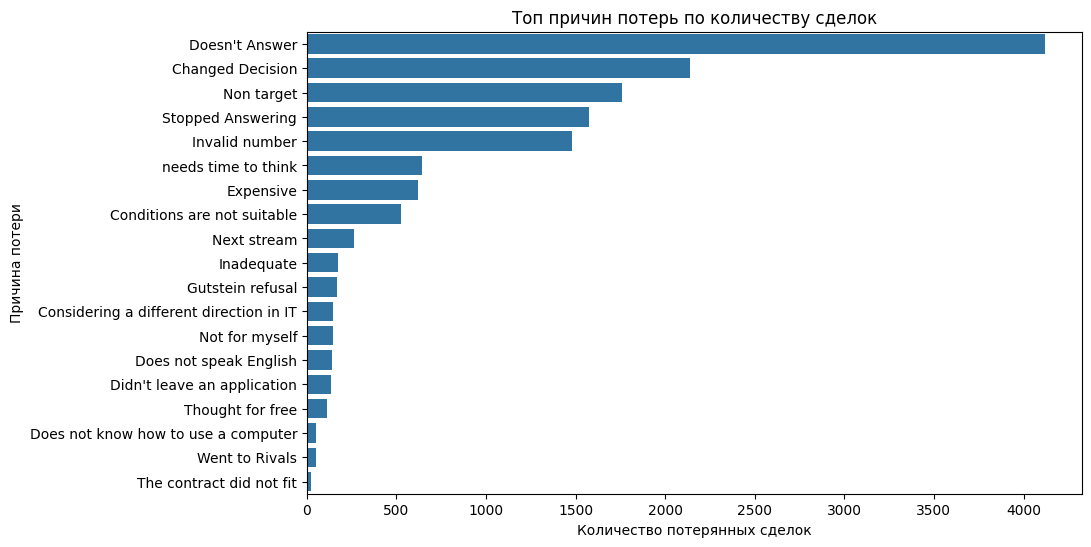

In [146]:
top_lost_reasons = lost_reason_analysis.head(20)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_lost_reasons, x="lost_deals_count",  y="lost_reason")

plt.title("Топ причин потерь по количеству сделок")
plt.xlabel("Количество потерянных сделок")
plt.ylabel("Причина потери")
plt.show()

#### График по потенциально недополученной сумме

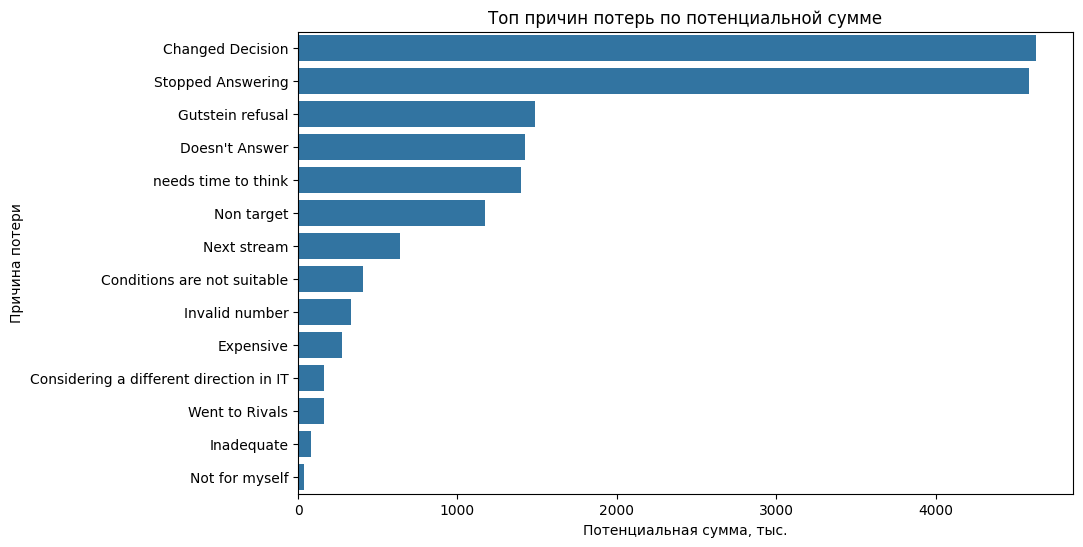

In [149]:
top_lost_reasons_by_amount["potential_lost_amount_k"] = (top_lost_reasons_by_amount["potential_lost_amount"] / 1000)

plt.figure(figsize=(10, 6))

sns.barplot(data=top_lost_reasons_by_amount, x="potential_lost_amount_k", y="lost_reason")

plt.title("Топ причин потерь по потенциальной сумме")
plt.xlabel("Потенциальная сумма, тыс.")
plt.ylabel("Причина потери")
plt.show()

#### Сравнение доли потерь и доли суммы

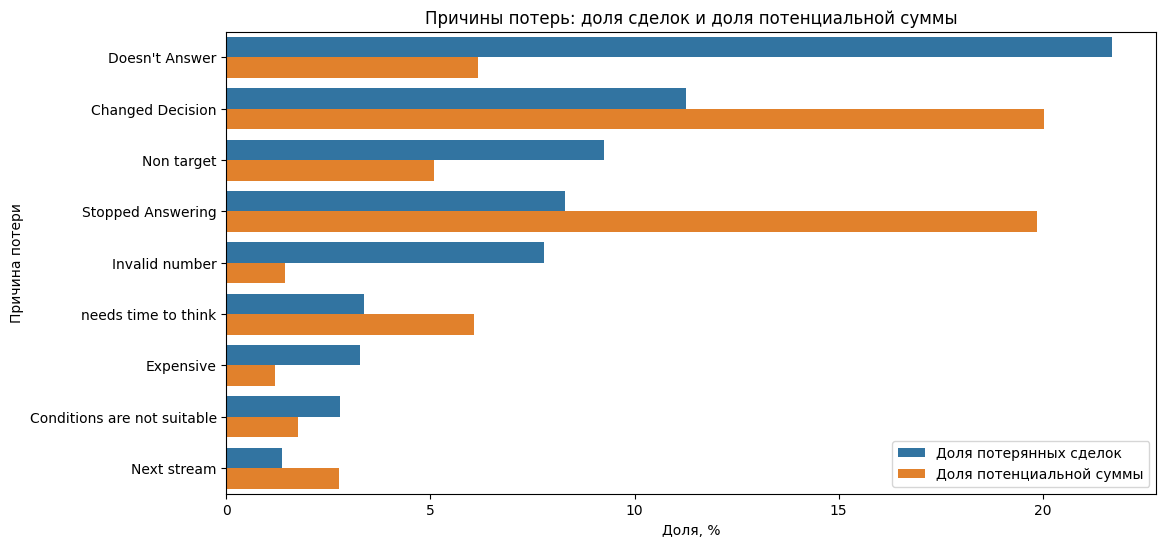

In [150]:
# Этот график помогает увидеть важное различие: одна причина может встречаться часто, но давать маленькую потенциальную сумму;
# другая причина может встречаться реже, но быть дорогой для бизнеса.

lost_reason_share_plot = lost_reason_analysis.head(10)[["lost_reason", "lost_deals_share", "potential_lost_amount_share"]].melt(
    id_vars="lost_reason", value_vars=["lost_deals_share", "potential_lost_amount_share"], var_name="metric", value_name="share")

lost_reason_share_plot["metric"] = lost_reason_share_plot["metric"].replace({"lost_deals_share": "Доля потерянных сделок", "potential_lost_amount_share": "Доля потенциальной суммы"})

plt.figure(figsize=(12, 6))

sns.barplot(data=lost_reason_share_plot, x="share", y="lost_reason", hue="metric")

plt.title("Причины потерь: доля сделок и доля потенциальной суммы")
plt.xlabel("Доля, %")
plt.ylabel("Причина потери")
plt.legend(title="")
plt.show()

#### Создаем словарь соответствий с логикой - конкретная причина из CRM → понятная бизнес-группа
- Берем только не студентов.
- Чистим пустые lost_reason.
- Смотрим исходные причины потерь.
- Создаем словарь группировки.
- Группируем причины в бизнес-категории.
- Считаем количество потерь, потенциальную сумму, доли.

In [157]:
lost_deals["lost_reason_clean"] = (lost_deals["lost_reason"].fillna("Причина не указана").astype(str).str.strip())

lost_deals.loc[lost_deals["lost_reason_clean"] == "", "lost_reason_clean"] = "Причина не указана"


lost_reason_group_map = {
    "Причина не указана": "Причина не указана",

    "Doesn't Answer": "Нет контакта / проблема связи",
    "Stopped Answering": "Нет контакта / проблема связи",
    "Invalid number": "Нет контакта / проблема связи",

    "Changed Decision": "Передумал / отложил решение",
    "needs time to think": "Передумал / отложил решение",
    "Next stream": "Передумал / отложил решение",

    "Non target": "Нецелевой лид / слабый интерес",
    "Inadequate": "Нецелевой лид / слабый интерес",
    "Didn't leave an application": "Нецелевой лид / слабый интерес",
    "Not for myself": "Нецелевой лид / слабый интерес",
    "Thought for free": "Нецелевой лид / слабый интерес",
    "Considering a different direction in IT": "Нецелевой лид / слабый интерес",

    "Expensive": "Цена / условия не подошли",
    "Conditions are not suitable": "Цена / условия не подошли",
    "The contract did not fit": "Цена / условия не подошли",

    "Does not speak English": "Язык / базовые навыки",
    "Does not know how to use a computer": "Язык / базовые навыки",

    "Went to Rivals": "Ушел к конкурентам"}

lost_deals["lost_reason_group"] = (lost_deals["lost_reason_clean"].map(lost_reason_group_map).fillna("Другое / специфичная причина"))

In [158]:
# Считаем причины потерь по исходному столбцу lost_reason:
# сколько сделок потеряно по каждой причине;
# какая потенциальная сумма была в этих сделках;
# какую долю занимает причина среди всех потерь;
# какую долю занимает причина в потенциально недополученной сумме.
    
lost_reason_group_analysis = (lost_deals.groupby("lost_reason_group", dropna=False).agg(
        lost_deals_count=("id", "count"),
        potential_lost_amount=("offer_total_amount", "sum"),
        avg_offer=("offer_total_amount", "mean")).reset_index())

lost_reason_group_analysis["lost_deals_share"] = (lost_reason_group_analysis["lost_deals_count"]
    / lost_reason_group_analysis["lost_deals_count"].sum() * 100).round(2)

lost_reason_group_analysis["potential_lost_amount_share"] = (lost_reason_group_analysis["potential_lost_amount"]
    / lost_reason_group_analysis["potential_lost_amount"].sum() * 100).round(2)

lost_reason_group_analysis["avg_offer"] = (lost_reason_group_analysis["avg_offer"].round(2))

lost_reason_group_analysis = lost_reason_group_analysis.sort_values("lost_deals_count", ascending=False)

lost_reason_group_analysis

,lost_reason_group,lost_deals_count,potential_lost_amount,avg_offer,lost_deals_share,potential_lost_amount_share
1,Нет контакта / проблема связи,7171,6342400.0,5411.60,37.77,27.45
4,Причина не указана,4729,6251898.0,9359.13,24.91,27.06
3,Передумал / отложил решение,3040,6671311.0,8076.65,16.01,28.88
2,Нецелевой лид / слабый интерес,2469,1470700.0,7659.90,13.01,6.37
6,Цена / условия не подошли,1170,692901.0,3553.34,6.16,3.00
7,Язык / базовые навыки,187,25000.0,1388.89,0.99,0.11
0,Другое / специфичная причина,170,1485700.0,9971.14,0.90,6.43
5,Ушел к конкурентам,48,164000.0,7454.55,0.25,0.71


#### Построим диаграмму показывающую структуру (доли) потерь в общем обьеме.

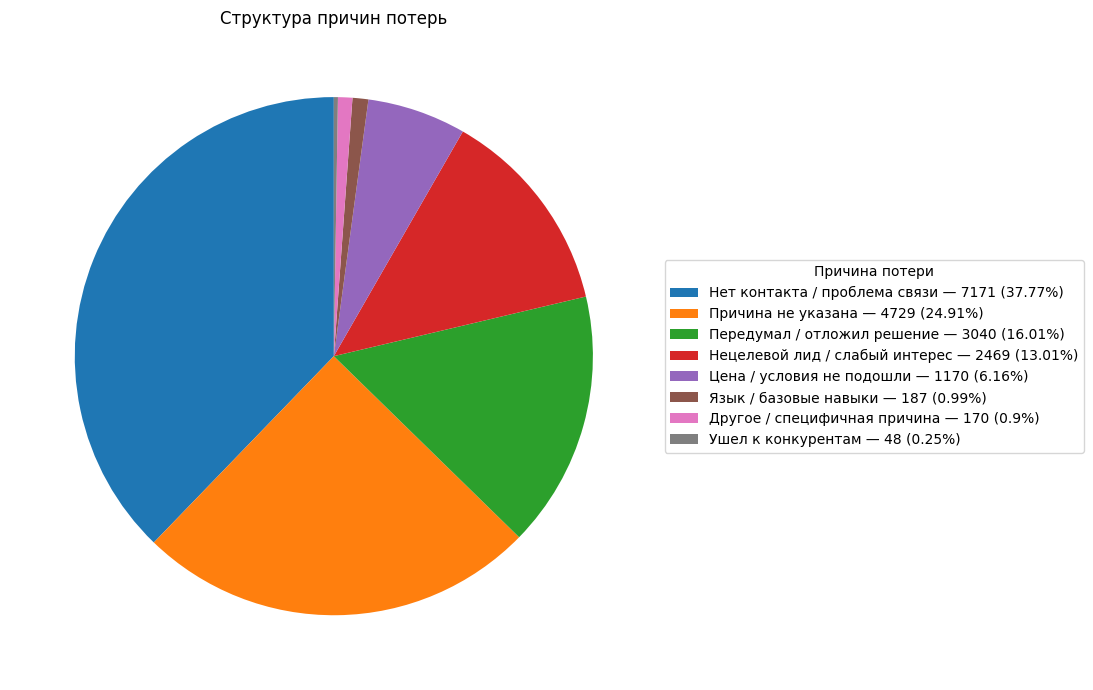

In [166]:
fig, ax = plt.subplots(figsize=(10, 7))

wedges, texts = ax.pie(lost_reason_group_analysis["lost_deals_count"], startangle=90)

legend_labels = [f"{row['lost_reason_group']} — {row['lost_deals_count']} ({row['lost_deals_share']}%)"
    for _, row in lost_reason_group_analysis.iterrows()]

ax.legend(wedges, legend_labels, title="Причина потери", loc="center left", bbox_to_anchor=(1, 0.5))

ax.set_title("Структура причин потерь")

plt.tight_layout()
plt.show()

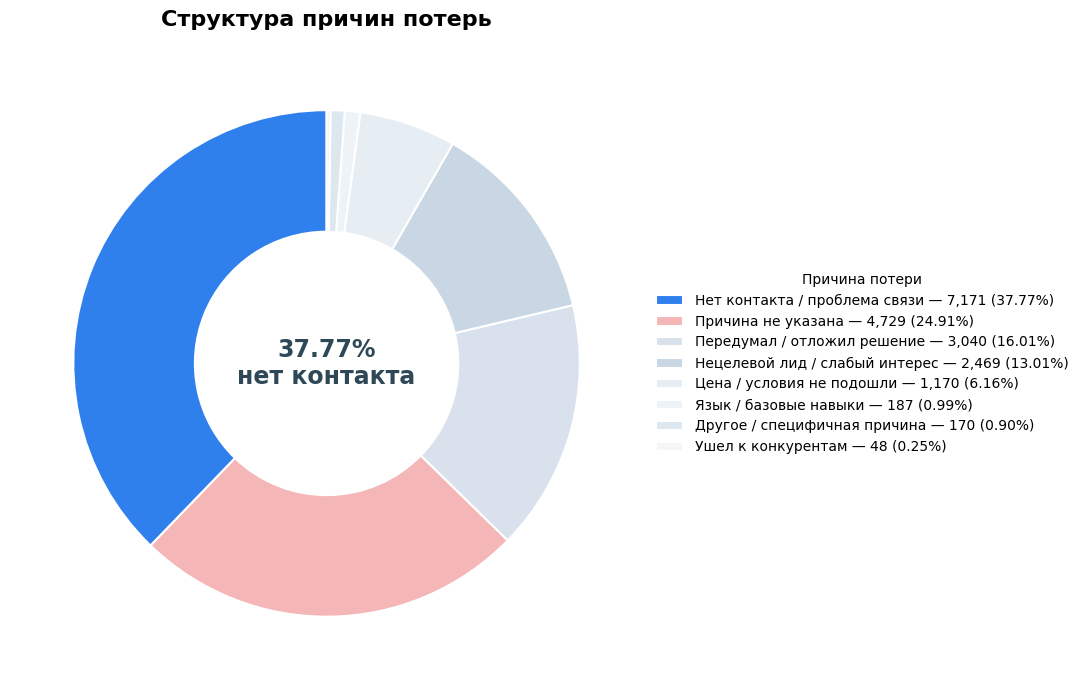

In [168]:
presentation_lost_reasons = (lost_reason_group_analysis.sort_values("lost_deals_count", ascending=False).copy())

colors_map = {
    "Нет контакта / проблема связи": "#2F80ED",
    "Причина не указана": "#F4B6B6",
    "Передумал / отложил решение": "#D9E2EC",
    "Нецелевой лид / слабый интерес": "#C9D6E3",
    "Цена / условия не подошли": "#E6EDF3",
    "Язык / базовые навыки": "#EEF3F7",
    "Ушел к конкурентам": "#F4F6F8",
    "Другое / специфичная причина": "#DDE7F0"}

chart_colors = [colors_map.get(reason, "#E9EFF5")
                for reason in presentation_lost_reasons["lost_reason_group"]]

no_contact_share = presentation_lost_reasons.loc[presentation_lost_reasons["lost_reason_group"] == "Нет контакта / проблема связи", "lost_deals_share"].iloc[0]

fig, ax = plt.subplots(figsize=(11, 7))

wedges, _ = ax.pie(presentation_lost_reasons["lost_deals_count"], startangle=90, colors=chart_colors, wedgeprops={
        "width": 0.48, "edgecolor": "white", "linewidth": 1.5})

ax.text(
    0,
    0,
    f"{no_contact_share:.2f}%\nнет контакта",
    ha="center",
    va="center",
    fontsize=17,
    fontweight="bold",
    color="#2F4858"
)

legend_labels = [
    f"{row['lost_reason_group']} — {row['lost_deals_count']:,} ({row['lost_deals_share']:.2f}%)"
    for _, row in presentation_lost_reasons.iterrows()
]

ax.legend(
    wedges,
    legend_labels,
    title="Причина потери",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10
)

ax.set_title(
    "Структура причин потерь",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.tight_layout()

output_path = (
    r"C:\Users\Admin\Desktop\ICH\Учеба, курсы в записи, домашки"
    r"\Финальный проект\дополнительные файлы\lost_reasons_presentation.png"
)

plt.savefig(
    output_path,
    dpi=220,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

#### Построим так же линейный график отражающий причины потерь во времени

In [161]:
lost_deals["created_month"] = (lost_deals["created_time"].dt.to_period("M").astype(str))

In [162]:
top_lost_groups = (lost_reason_group_analysis.sort_values("lost_deals_count", ascending=False).head(5)["lost_reason_group"])

lost_reason_monthly = (lost_deals[lost_deals["lost_reason_group"].isin(top_lost_groups)]
    .groupby(["created_month", "lost_reason_group"]).agg(lost_deals_count=("id", "count")).reset_index())

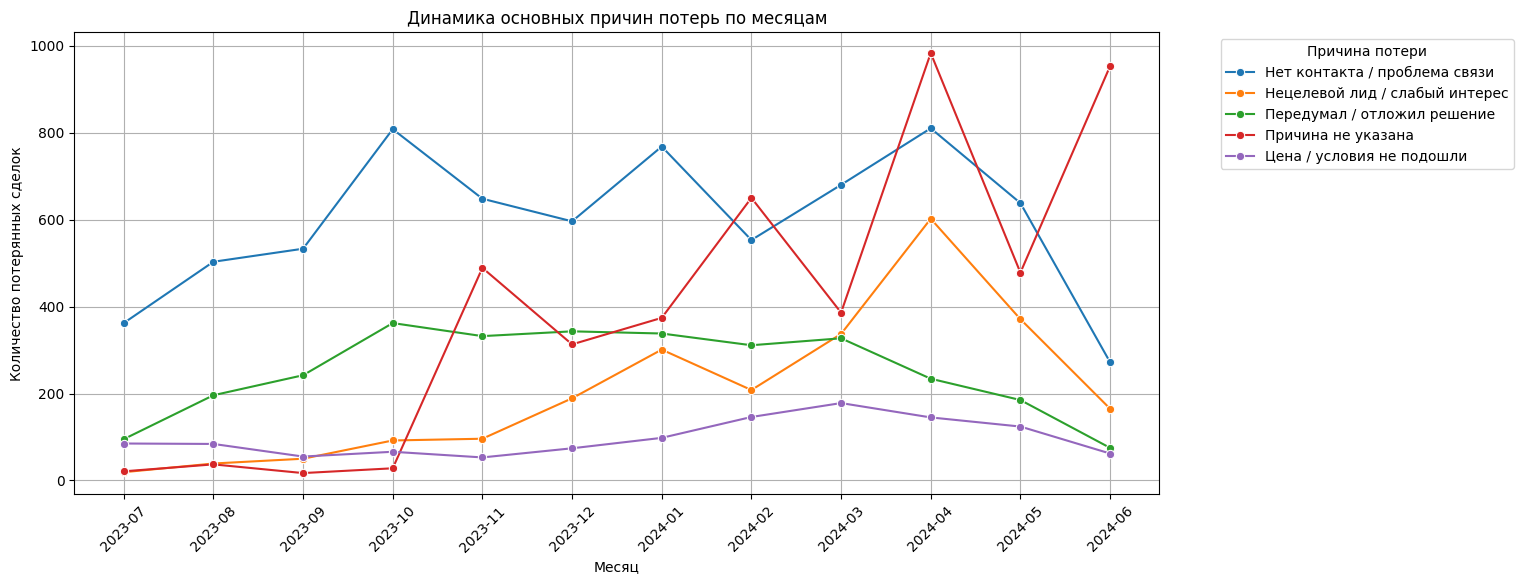

In [163]:
plt.figure(figsize=(14, 6))

sns.lineplot(data=lost_reason_monthly, x="created_month", y="lost_deals_count", hue="lost_reason_group", marker="o")

plt.title("Динамика основных причин потерь по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество потерянных сделок")
plt.xticks(rotation=45)
plt.legend(title="Причина потери", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

### Вывод по причинам потерь

Для анализа причин потерь были рассмотрены только лиды, которые не стали студентами. Это позволяет сфокусироваться на тех сделках, где школа не получила оплату и обучение не началось.

Причины потерь были проанализированы по количеству потерянных сделок и по потенциально недополученной сумме. Это важно, потому что самая частая причина потери не всегда является самой дорогой для бизнеса.

Отдельно была рассчитана доля каждой причины в общем количестве потерь и в потенциальной сумме. Такой подход помогает выделить причины, которые могут быть приоритетными для дальнейшей работы отдела продаж и маркетинга.

Потенциально недополученная сумма не является реальной потерянной выручкой, потому что клиент мог не оплатить обучение по разным причинам. Но этот показатель полезен как ориентир для поиска точек роста.

Дополнительно причины потерь были объединены в более крупные бизнес-категории. Это нужно, потому что отдельные значения `lost_reason` могут быть слишком детальными и плохо подходить для стратегического вывода.

Группировка позволяет посмотреть на потери с точки зрения зон ответственности бизнеса: цена, отсутствие контакта с клиентом, отсутствие интереса, ограничения по времени или расписанию, требования к языку, а также технические причины вроде дублей в CRM.

`Как показал наш анализ`, наиболее важная зона роста — это контакт с клиентом. Большая часть потерянных сделок связана с тем, что клиент не отвечает, перестает отвечать или указан некорректный номер. Это хорошо связывается с анализом звонков и SLA: если улучшить скорость первого касания и качество дозвона, можно повлиять на значимую часть потерь.

Также важной проблемой является большое количество сделок без указанной причины потери. Это ограничивает качество анализа и говорит о необходимости лучше заполнять CRM. Без корректной причины отказа бизнесу сложнее понять, что именно нужно улучшать.

## Таким образом, блок причин потерь может стать основой для гипотезы: `Предпологаем, что улучшение первого контакта с клиентом и стандартизация фиксации причин отказа в CRM должны повысить конверсию из лида в студента`, т.е. основная зона роста не просто “больше рекламы”, а улучшение контакта с лидом + качество CRM + работа с нецелевыми лидами.

# Итоговые выводы по бизнес-аналитике

В рамках бизнес-аналитики были рассмотрены ключевые этапы работы онлайн-школы: привлечение лидов, обработка заявок, звонки, работа менеджеров, продажи по продуктам, выручка и причины потерь клиентов.

## 1. Общая воронка

Была построена воронка от рекламных кликов к лидам и далее к студентам. Такой подход позволяет разделить две разные зоны ответственности: маркетинг отвечает за привлечение качественного трафика и заявок, а продажи — за превращение лидов в студентов.

Важно анализировать не только итоговое количество студентов, но и промежуточные этапы. Если кликов много, но лидов мало, проблема может быть в рекламе или посадочной странице. Если лидов много, но студентов мало, проблема может быть в качестве лидов, скорости обработки или работе отдела продаж.

## 2. Деньги и выручка

Реальная выручка считалась только по студентам, так как по условиям проекта факт обучения определяется через `months_of_study`. Это важно, потому что суммы в сделках без обучения нельзя считать полученными деньгами.

Дополнительно была рассмотрена динамика выручки по месяцам, средний и медианный платеж, а также потенциально недополученная сумма по лидам, которые не стали студентами. Такой подход помогает увидеть не только сколько денег школа получила, но и где может находиться финансовый потенциал роста.

## 3. Источники и рекламные кампании

Источники были проанализированы по количеству лидов, студентов, выручке, расходам, CAC и ROMI. Это позволило оценить не только объем трафика, но и его качество.

Отдельно были рассмотрены рекламные кампании в трех разрезах: по количеству лидов, по конверсии и по выручке. Такой подход помогает разделить три разных вопроса: какие кампании дают объем, какие дают качественных лидов, а какие реально приносят деньги.

## 4. Менеджеры

Менеджеры были сравнены по количеству сделок, количеству студентов, выручке, среднему платежу, конверсии и SLA. Это позволяет смотреть не только на активность менеджера, но и на результат его работы.

Также были выделены проблемные сделки, где клиент считается студентом, но сумма оплаты отсутствует или равна нулю. Такие случаи важны для контроля качества данных и корректного расчета выручки.

## 5. Звонки

Звонки были проанализированы как важный этап между лидом и покупкой. Были рассмотрены общее количество звонков, успешные звонки, длительность разговоров и связь этих показателей с конверсией в студента.

Отдельно был выделен признак успешного контакта. Он может быть полезен как промежуточная метрика: сначала клиент должен выйти на контакт с менеджером, и только после этого возможна продажа.

## 6. Продукты

Продукты были проанализированы по количеству лидов, студентов, выручке, среднему и медианному платежу, доле студентов и доле выручки.

Такой анализ показывает, какие направления дают основной объем продаж, какие приносят больше денег, а какие могут быть перспективными за счет более высокой конверсии или среднего платежа.

## 7. Причины потерь

Для некупивших лидов были проанализированы причины потерь. Они были рассмотрены по количеству потерянных сделок и по потенциально недополученной сумме.

Дополнительно причины были сгруппированы в более крупные бизнес-категории: цена, отсутствие контакта, отсутствие интереса, расписание, языковые требования, дубли и другие причины. Проанализирована структура причин потери лидов а так же динамика потерь по группа во времени.

## Общий вывод

Главная точка роста находится не в одном отдельном месте, а на стыке маркетинга и продаж. Бизнесу важно не только увеличивать количество лидов, но и контролировать их качество, скорость обработки, успешность контакта и конверсию в студента. Выдвинута первая гипотеза - `основная зона роста не просто “больше рекламы”, а улучшение контакта с лидом + качество CRM + работа с нецелевыми лидами`.

На следующем этапе необходимо перейти к юнит-экономике: рассчитать стоимость привлечения, окупаемость каналов, средний чек, вклад продуктов и рекламных источников. Это позволит точнее определить, какие направления стоит масштабировать, а какие требуют оптимизации.